In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/frames_errors.csv", header=None)
df.columns = [
    "block_id",
    "frame_idx",
    "E_mu_Z",
    "E_mu_phys_est",
    "E_mu_X",
    "E_nu1_X",
    "E_nu2_X",
    "E_nu1_Z",
    "E_nu2_Z",
    "N_mu_X",
    "M_mu_XX",
    "M_mu_XZ",
    "M_mu_X",
    "N_mu_Z",
    "M_mu_ZZ",
    "M_mu_Z",
    "N_nu1_X",
    "M_nu1_XX",
    "M_nu1_XZ",
    "M_nu1_X",
    "N_nu1_Z",
    "M_nu1_ZZ",
    "M_nu1_Z",
    "N_nu2_X",
    "M_nu2_XX",
    "M_nu2_XZ",
    "M_nu2_X",
    "N_nu2_Z",
    "M_nu2_ZZ",
    "M_nu2_Z",
    "nTot",
    "bayesImVoltage",
    "opticalPower",
    "polarizerVoltages[0]",
    "polarizerVoltages[1]",
    "polarizerVoltages[2]",
    "polarizerVoltages[3]",
    "temp_1",
    "biasVoltage_1",
    "temp_2",
    "biasVoltage_2",
    "synErr",
    "N_EC_rounds",
    "maintenance_flag",
    "estimator_name",
    "f_EC",
    "E_mu_Z_est",
    "R",
    "s",
    "p",
]

df_base = df.drop(
    [
        "E_mu_phys_est",
        "f_EC",
    ],
    axis=1,
)
print(f"Количество пропусков: {df.isna().sum().sum()}")

df = df_base.copy()

df = df.rename(
    columns={
        "block_id": "id",
        "frame_idx": "date",
    }
)

# Смотрим на длину временных рядов по количеству фреймов
timestamp_counts = df.groupby("id")["date"].nunique()
print("Количество фреймов/Количество рядов")
print(timestamp_counts.value_counts())



Количество пропусков: 579
Количество фреймов/Количество рядов
date
399    569
400    251
398      2
390      1
Name: count, dtype: int64


In [2]:
# ==============================================================================
# 1.1. Импорт библиотек и загрузка данных
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем стиль для графиков для лучшей читаемости
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

print("Библиотеки успешно импортированы.")

# --- Загрузка данных ---
# [Важно!] Убедитесь, что путь к файлу указан верно относительно вашего ноутбука.
# Судя по структуре репозитория, он должен быть примерно таким:
file_path = '../data/raw/frames_errors.csv' 

try:
    #df = pd.read_csv(file_path)
    print(f"Датасет успешно загружен. Путь: '{file_path}'")
    
    # ==============================================================================
    # 1.2. Общая информация и первые строки
    # ==============================================================================
    print("\n--- Общая информация о датасете ---")
    print(f"Размер датасета (строки, колонки): {df.shape}")
    
    print("\n--- Первые 5 строк данных ---")
    display(df.head())
    
    print("\n--- Техническая информация по колонкам (типы данных, пропуски) ---")
    df.info()

except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути '{file_path}'.")
    print("Пожалуйста, проверьте путь к файлу и перезапустите ячейку.")
    df = None # Создаем пустую переменную, чтобы следующие ячейки не вызывали ошибок

Библиотеки успешно импортированы.
Датасет успешно загружен. Путь: '../data/raw/frames_errors.csv'

--- Общая информация о датасете ---
Размер датасета (строки, колонки): (328617, 48)

--- Первые 5 строк данных ---


,id,date,E_mu_Z,E_mu_X,E_nu1_X,E_nu2_X,E_nu1_Z,E_nu2_Z,N_mu_X,M_mu_XX,...,temp_2,biasVoltage_2,synErr,N_EC_rounds,maintenance_flag,estimator_name,E_mu_Z_est,R,s,p
0,989611274,0,0.10787,0.00000,0.00000,0.00000,0.00000,0.00000,5540263.0,442.0,...,0.0,0.0,0.0,0,1,EMA,0.03297,0.75,3339,1461
1,989611274,1,0.10713,0.04072,0.11111,0.50000,0.04723,0.40260,5539181.0,481.0,...,0.0,0.0,0.0,44,1,EMA,0.05794,0.65,3584,1216
2,989611274,2,0.10676,0.03742,0.00000,0.66667,0.05041,0.36842,5446219.0,482.0,...,0.0,0.0,0.0,20,1,EMA,0.07434,0.60,3946,854
3,989611274,3,0.10820,0.02697,0.10526,0.66667,0.06257,0.45570,5441014.0,477.0,...,0.0,0.0,0.0,12,1,EMA,0.08515,0.55,3539,1261
4,989611274,4,0.11996,0.03983,0.15385,1.00000,0.06999,0.40541,5445731.0,452.0,...,0.0,0.0,0.0,11,1,EMA,0.09283,0.50,2746,2054



--- Техническая информация по колонкам (типы данных, пропуски) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328617 entries, 0 to 328616
Data columns (total 48 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    328617 non-null  int64  
 1   date                  328617 non-null  int64  
 2   E_mu_Z                328617 non-null  float64
 3   E_mu_X                328617 non-null  float64
 4   E_nu1_X               328617 non-null  float64
 5   E_nu2_X               328617 non-null  float64
 6   E_nu1_Z               328617 non-null  float64
 7   E_nu2_Z               328617 non-null  float64
 8   N_mu_X                328617 non-null  float64
 9   M_mu_XX               328617 non-null  float64
 10  M_mu_XZ               328617 non-null  float64
 11  M_mu_X                328617 non-null  float64
 12  N_mu_Z                328617 non-null  float64
 13  M_mu_ZZ               328617 non-nul

In [3]:
df.to_csv('../data/raw/frames_errors.csv', index=False)

In [19]:
# ==============================================================================
# 1.3. Анализ идентификаторов и категорий
# ==============================================================================
if df is not None:
    print("\n--- Анализ ключевых идентификаторов и категорий ---")
    
    # Количество уникальных сессий/блоков
    num_unique_blocks = df['id'].nunique()
    print(f"Количество уникальных сессий (block_id): {num_unique_blocks}")
    
    # Распределение по типам estimator_name
    print("\nРаспределение по 'estimator_name':")
    print(df['maintenance_flag'].value_counts())
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ ключевых идентификаторов и категорий ---
Количество уникальных сессий (block_id): 823

Распределение по 'estimator_name':
maintenance_flag
0    327703
1       914
Name: count, dtype: int64



--- Анализ пропущенных значений ---
Пропуски по колонкам:


,Количество пропусков,"Процент пропусков, %"


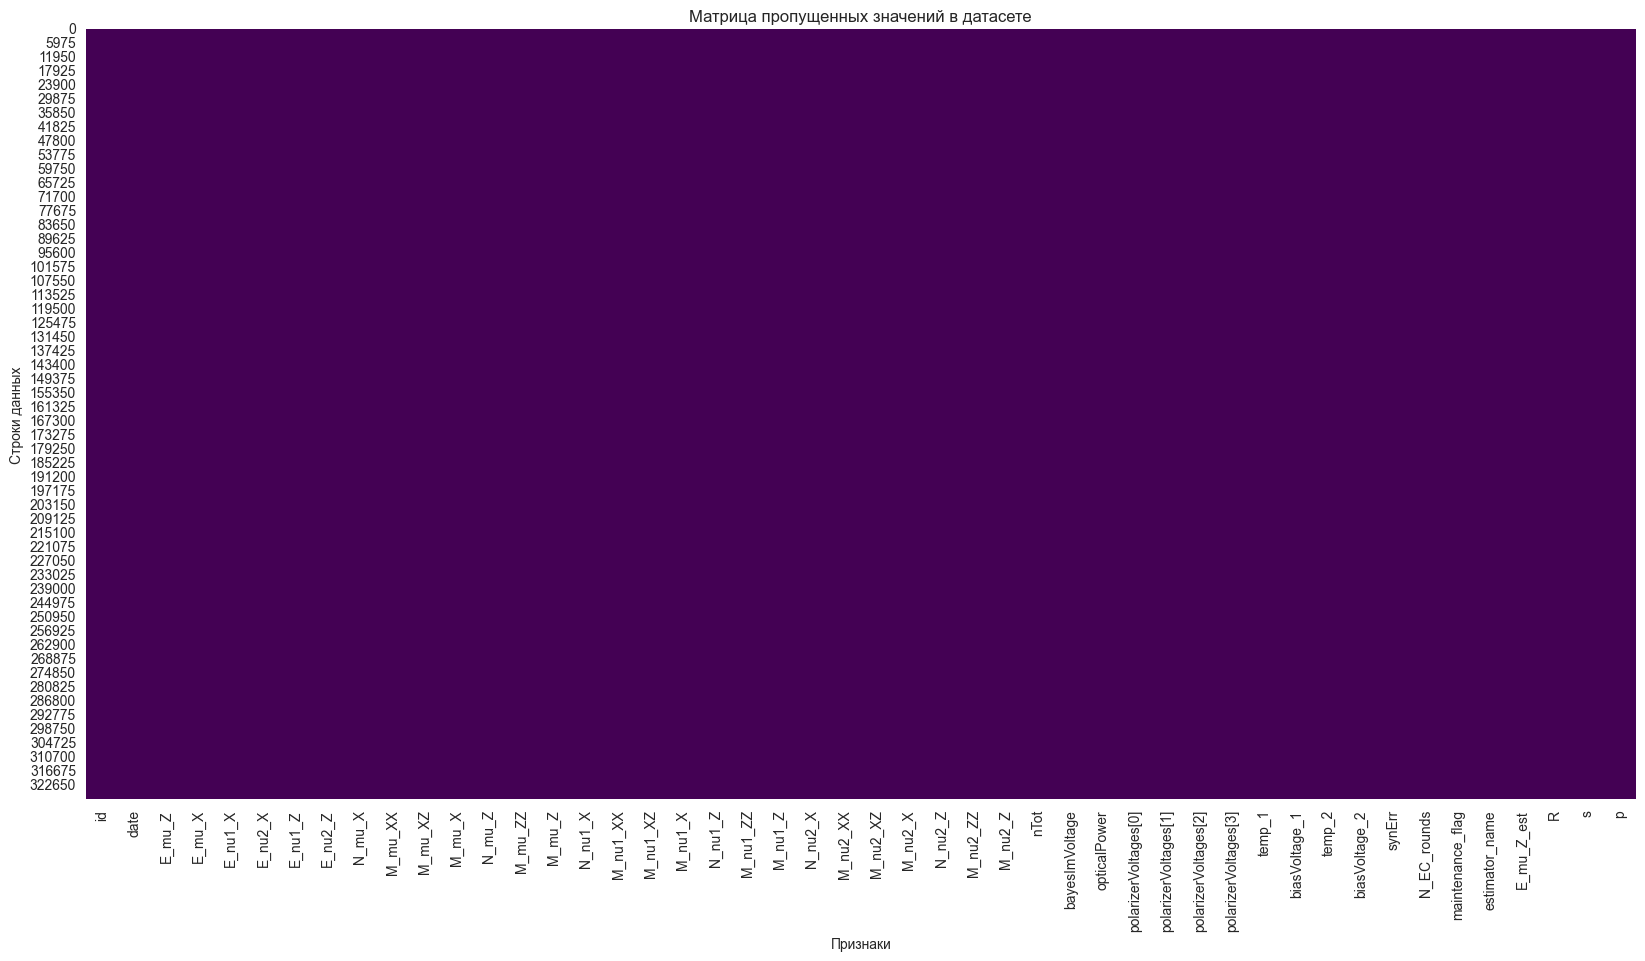

In [5]:
# ==============================================================================
# 1.4. Детальный анализ пропущенных значений
# ==============================================================================
if df is not None:
    print("\n--- Анализ пропущенных значений ---")
    
    # Считаем пропуски в каждой колонке
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100
    
    # Создаем DataFrame для удобного отображения
    missing_df = pd.DataFrame({
        'Количество пропусков': missing_values,
        'Процент пропусков, %': missing_percentage
    })
    
    # Отображаем только те колонки, где есть пропуски, сортируя по убыванию
    print("Пропуски по колонкам:")
    display(missing_df[missing_df['Количество пропусков'] > 0].sort_values(by='Количество пропусков', ascending=False))

    # Визуализация матрицы пропусков
    plt.figure(figsize=(20, 10))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Матрица пропущенных значений в датасете')
    plt.xlabel('Признаки')
    plt.ylabel('Строки данных')
    plt.show()
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

Анализируем 328617 непропущенных значений 'E_mu_Z'.


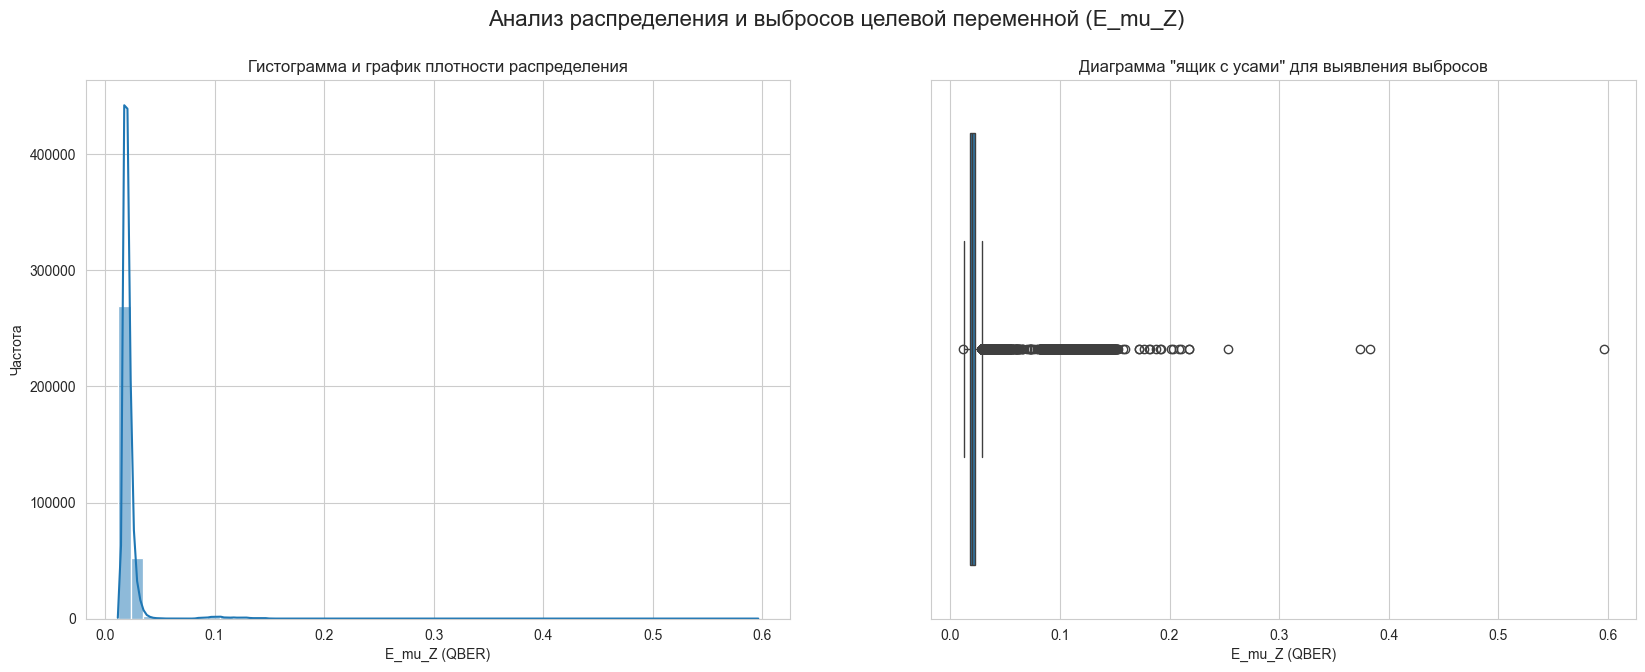

In [6]:
# ==============================================================================
# 2.1. Анализ распределения E_mu_Z
# ==============================================================================
if df is not None:
    # Проверяем, есть ли пропуски в целевой переменной, и если да, работаем с данными без них
    target_series = df['E_mu_Z'].dropna()
    print(f"Анализируем {len(target_series)} непропущенных значений 'E_mu_Z'.")

    # Создаем фигуру с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle('Анализ распределения и выбросов целевой переменной (E_mu_Z)', fontsize=16)

    # Гистограмма и KDE-график
    sns.histplot(target_series, kde=True, ax=axes[0], bins=50)
    axes[0].set_title('Гистограмма и график плотности распределения')
    axes[0].set_xlabel('E_mu_Z (QBER)')
    axes[0].set_ylabel('Частота')

    # Boxplot для оценки выбросов
    sns.boxplot(x=target_series, ax=axes[1])
    axes[1].set_title('Диаграмма "ящик с усами" для выявления выбросов')
    axes[1].set_xlabel('E_mu_Z (QBER)')

    plt.show()
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

In [7]:
# ==============================================================================
# 2.2. Расчет описательных статистик
# ==============================================================================
if df is not None:
    print("--- Описательные статистики для E_mu_Z ---")
    # Используем to_frame() для более красивого вывода в Jupyter
    display(target_series.describe().to_frame())
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Описательные статистики для E_mu_Z ---


,E_mu_Z
count,328617.000000
mean,0.021936
std,0.011728
min,0.011730
25%,0.018120
50%,0.019930
75%,0.022320
max,0.596320


Найдены следующие колонки с показателями ошибок: 
['E_mu_Z', 'E_mu_X', 'E_nu1_X', 'E_nu2_X', 'E_nu1_Z', 'E_nu2_Z', 'E_mu_Z_est']



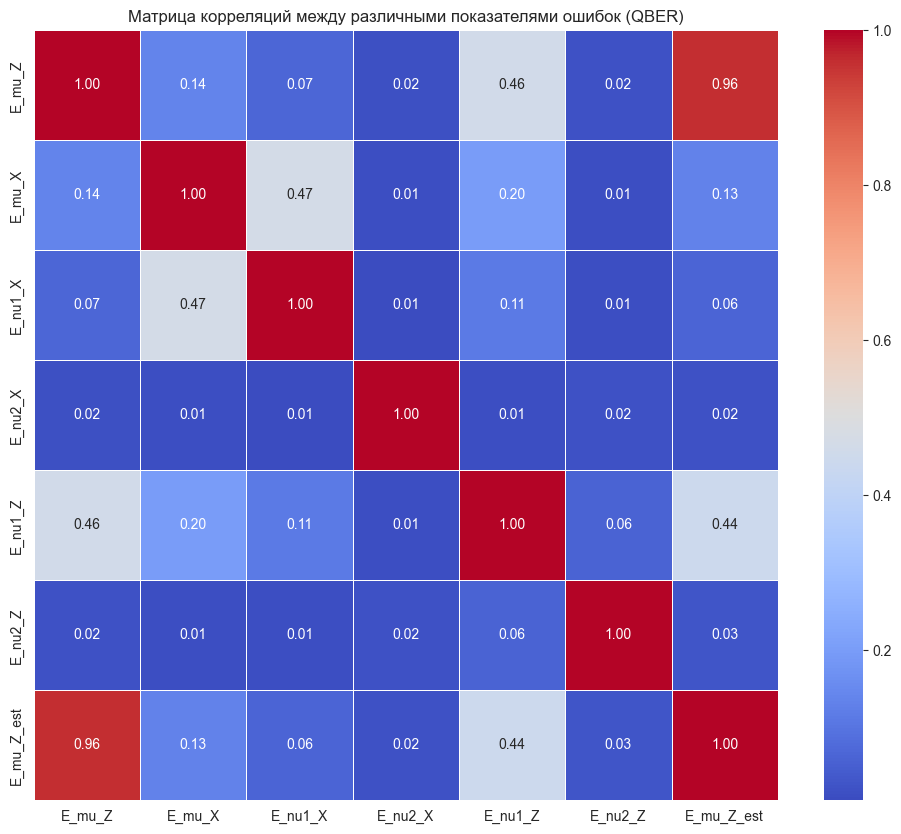

In [8]:
# ==============================================================================
# 2.3. Корреляция между различными типами ошибок (QBER)
# ==============================================================================
if df is not None:
    # Находим все колонки, связанные с ошибками (содержат 'E_')
    error_cols = [col for col in df.columns if 'E_' in col]
    print(f"Найдены следующие колонки с показателями ошибок: \n{error_cols}\n")
    
    # Рассчитываем матрицу корреляций
    correlation_matrix = df[error_cols].corr()
    
    # Визуализируем матрицу
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Матрица корреляций между различными показателями ошибок (QBER)')
    plt.show()
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Расчет корреляции всех числовых признаков с E_mu_Z ---


C:\Users\iboro\AppData\Local\Temp\ipykernel_15980\1272472005.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='vlag')


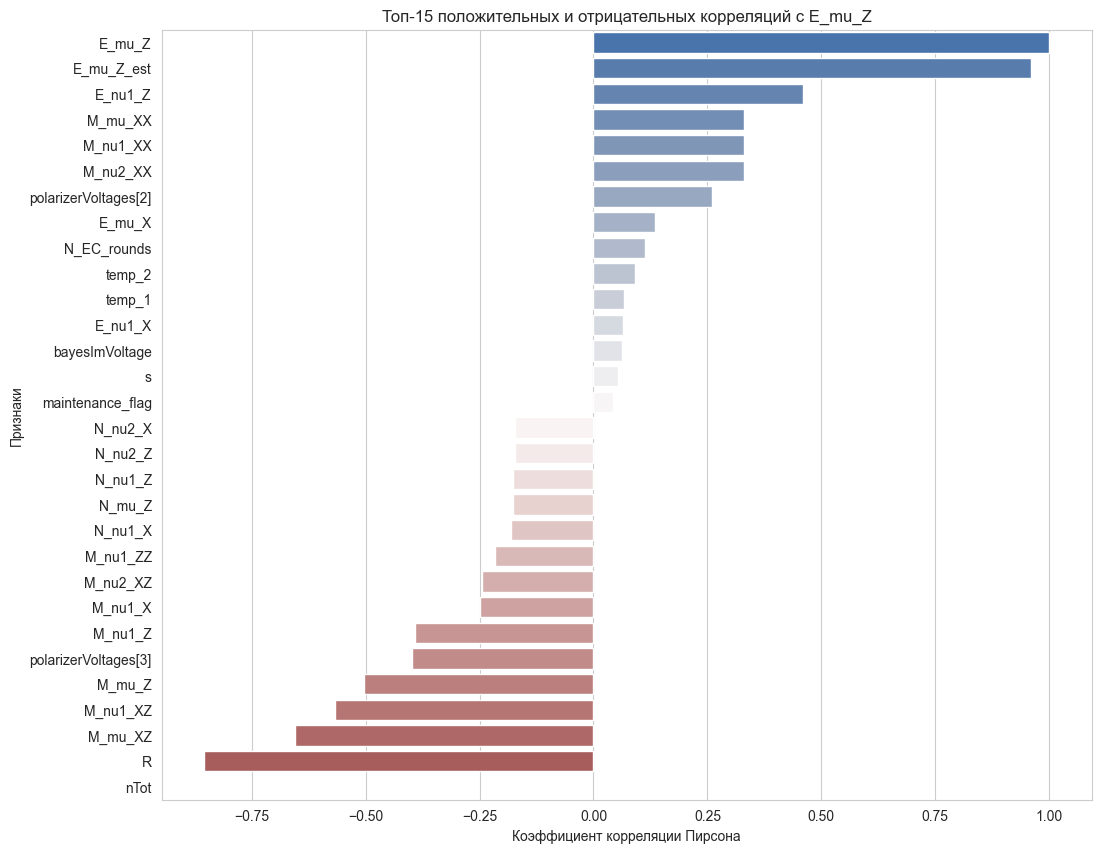


Топ-5 наиболее скоррелированных не-ошибочных признаков:
['M_mu_XX', 'M_nu1_XX', 'M_nu2_XX', 'polarizerVoltages[2]', 'N_EC_rounds']


In [9]:
# ==============================================================================
# 3.1. Корреляция числовых признаков с целевой переменной E_mu_Z
# ==============================================================================
if df is not None:
    print("--- Расчет корреляции всех числовых признаков с E_mu_Z ---")
    
    # Выбираем только числовые колонки для расчета корреляции
    numeric_df = df.select_dtypes(include=np.number)
    
    # Рассчитываем корреляцию всех признаков с нашей целевой переменной
    correlations_with_target = numeric_df.corr()['E_mu_Z'].sort_values(ascending=False)
    
    # Визуализируем наиболее сильно скоррелированные признаки
    plt.figure(figsize=(12, 10))
    # Берем топ-15 и последние 15 признаков для наглядности
    top_correlations = pd.concat([correlations_with_target.head(15), correlations_with_target.tail(15)])
    
    sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='vlag')
    plt.title('Топ-15 положительных и отрицательных корреляций с E_mu_Z')
    plt.xlabel('Коэффициент корреляции Пирсона')
    plt.ylabel('Признаки')
    plt.show()

    # Сохраним названия топ-5 признаков (исключая саму себя и другие 'E_' признаки)
    # для следующего шага
    top_predictors = correlations_with_target.drop(
        labels=[col for col in correlations_with_target.index if 'E_' in col]
    ).head(5).index.tolist()
    
    print("\nТоп-5 наиболее скоррелированных не-ошибочных признаков:")
    print(top_predictors)

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ характера связи для топ-5 предикторов ---


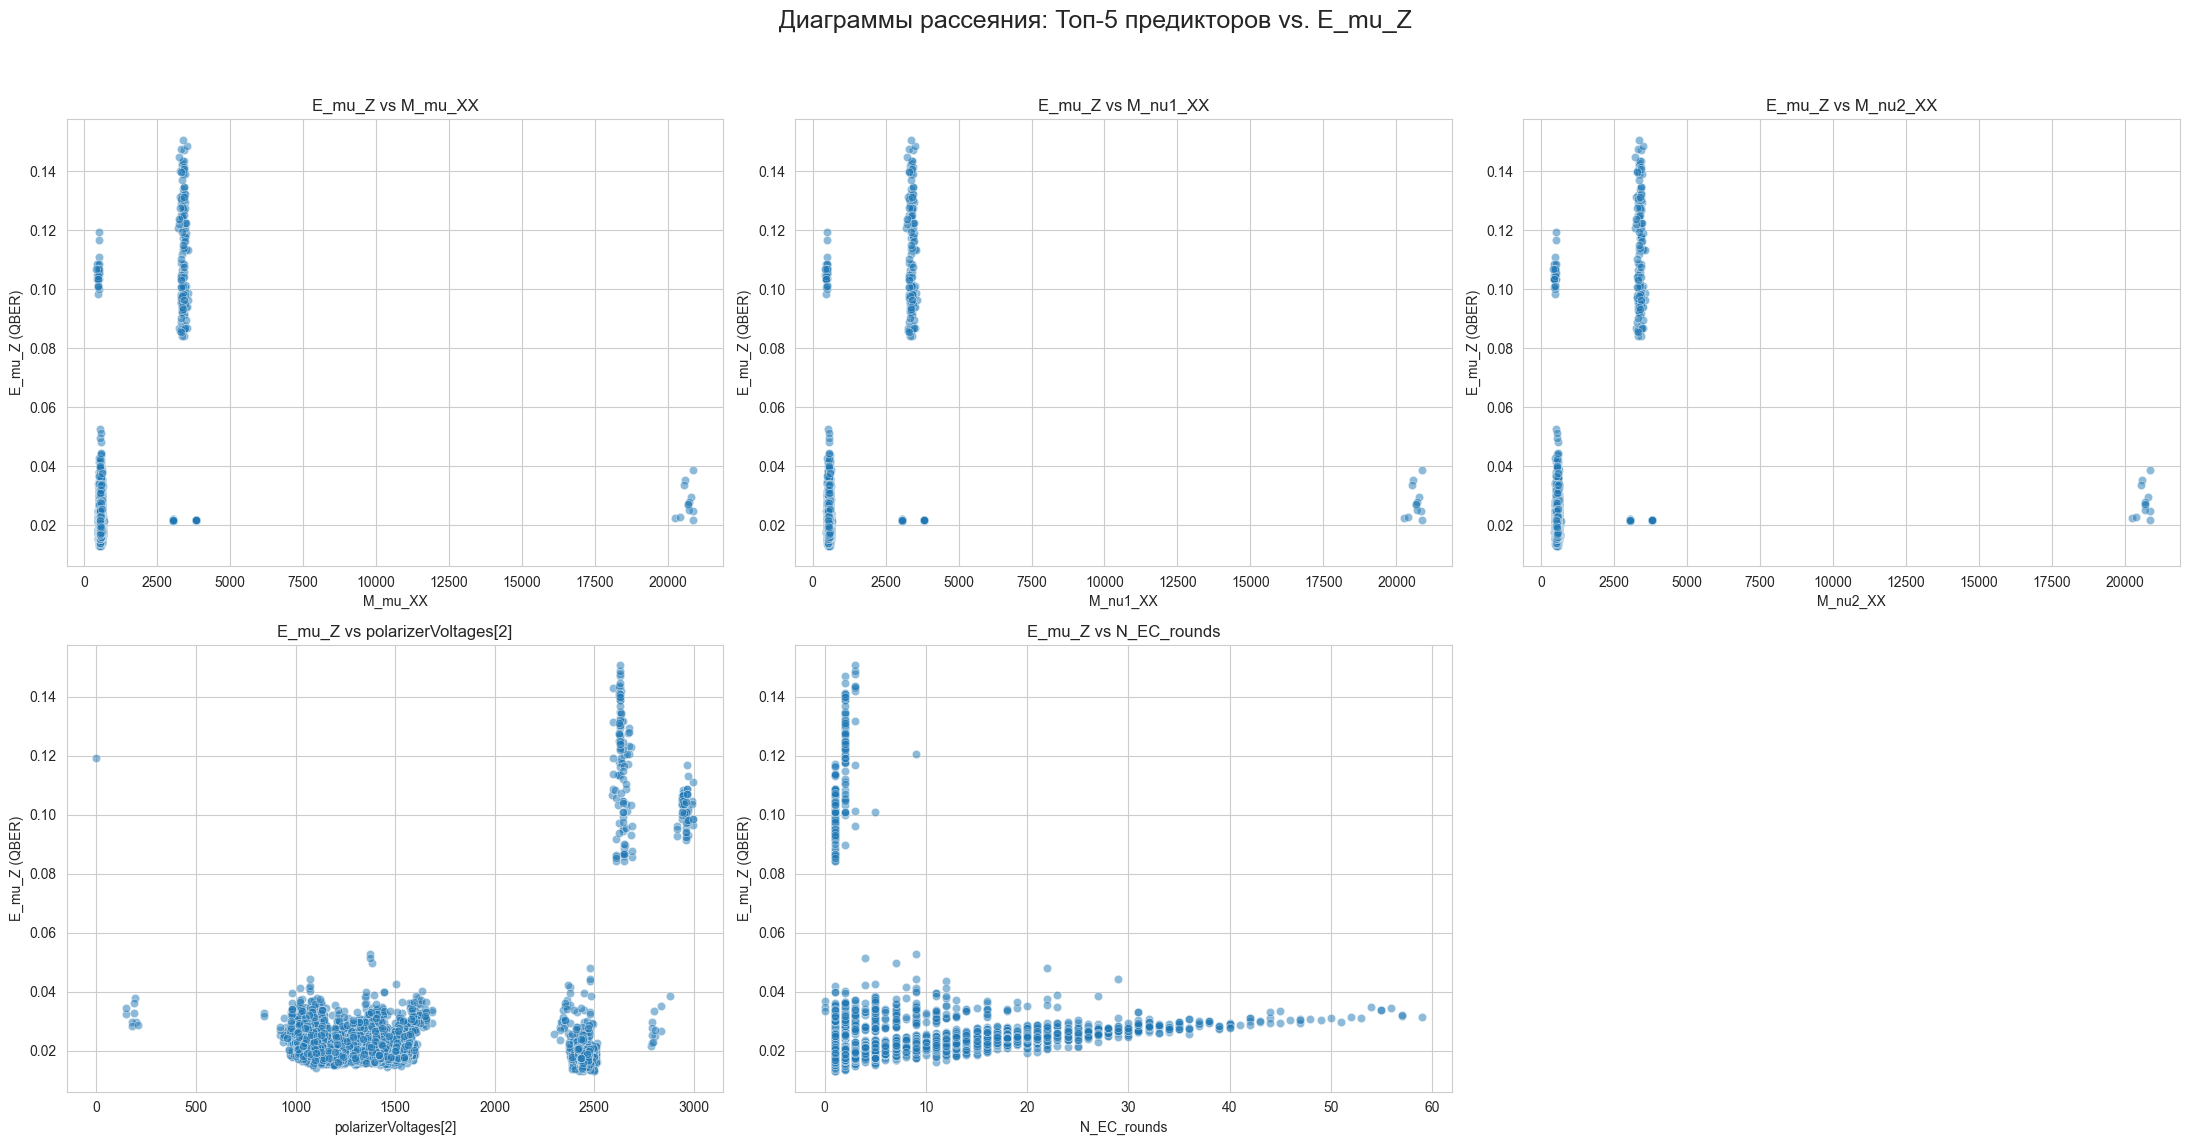

In [10]:
# ==============================================================================
# 3.2. Визуальный анализ зависимостей (Scatter Plots)
# ==============================================================================
if df is not None and 'top_predictors' in locals():
    print(f"\n--- Анализ характера связи для топ-5 предикторов ---")
    
    # Чтобы избежать долгой отрисовки и наложения точек, используем случайную выборку
    df_sample = df.sample(n=min(10000, len(df)), random_state=42)

    # Создаем сетку графиков
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle('Диаграммы рассеяния: Топ-5 предикторов vs. E_mu_Z', fontsize=18)
    
    # `axes.flatten()` позволяет удобно итерироваться по сетке графиков
    axes_flat = axes.flatten()
    
    for i, col in enumerate(top_predictors):
        sns.scatterplot(data=df_sample, x=col, y='E_mu_Z', ax=axes_flat[i], alpha=0.5)
        axes_flat[i].set_title(f'E_mu_Z vs {col}')
        axes_flat[i].set_xlabel(col)
        axes_flat[i].set_ylabel('E_mu_Z (QBER)')
    
    # Скрываем лишний пустой график, если он есть
    if len(top_predictors) < len(axes_flat):
        for i in range(len(top_predictors), len(axes_flat)):
            fig.delaxes(axes_flat[i])
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Датафрейм не загружен или переменная top_predictors не создана.")

--- Анализ временной динамики внутри нескольких случайных сессий ---
Выбраны случайные block_id для анализа: [1786006754  326114427 1138466018 1799470564]


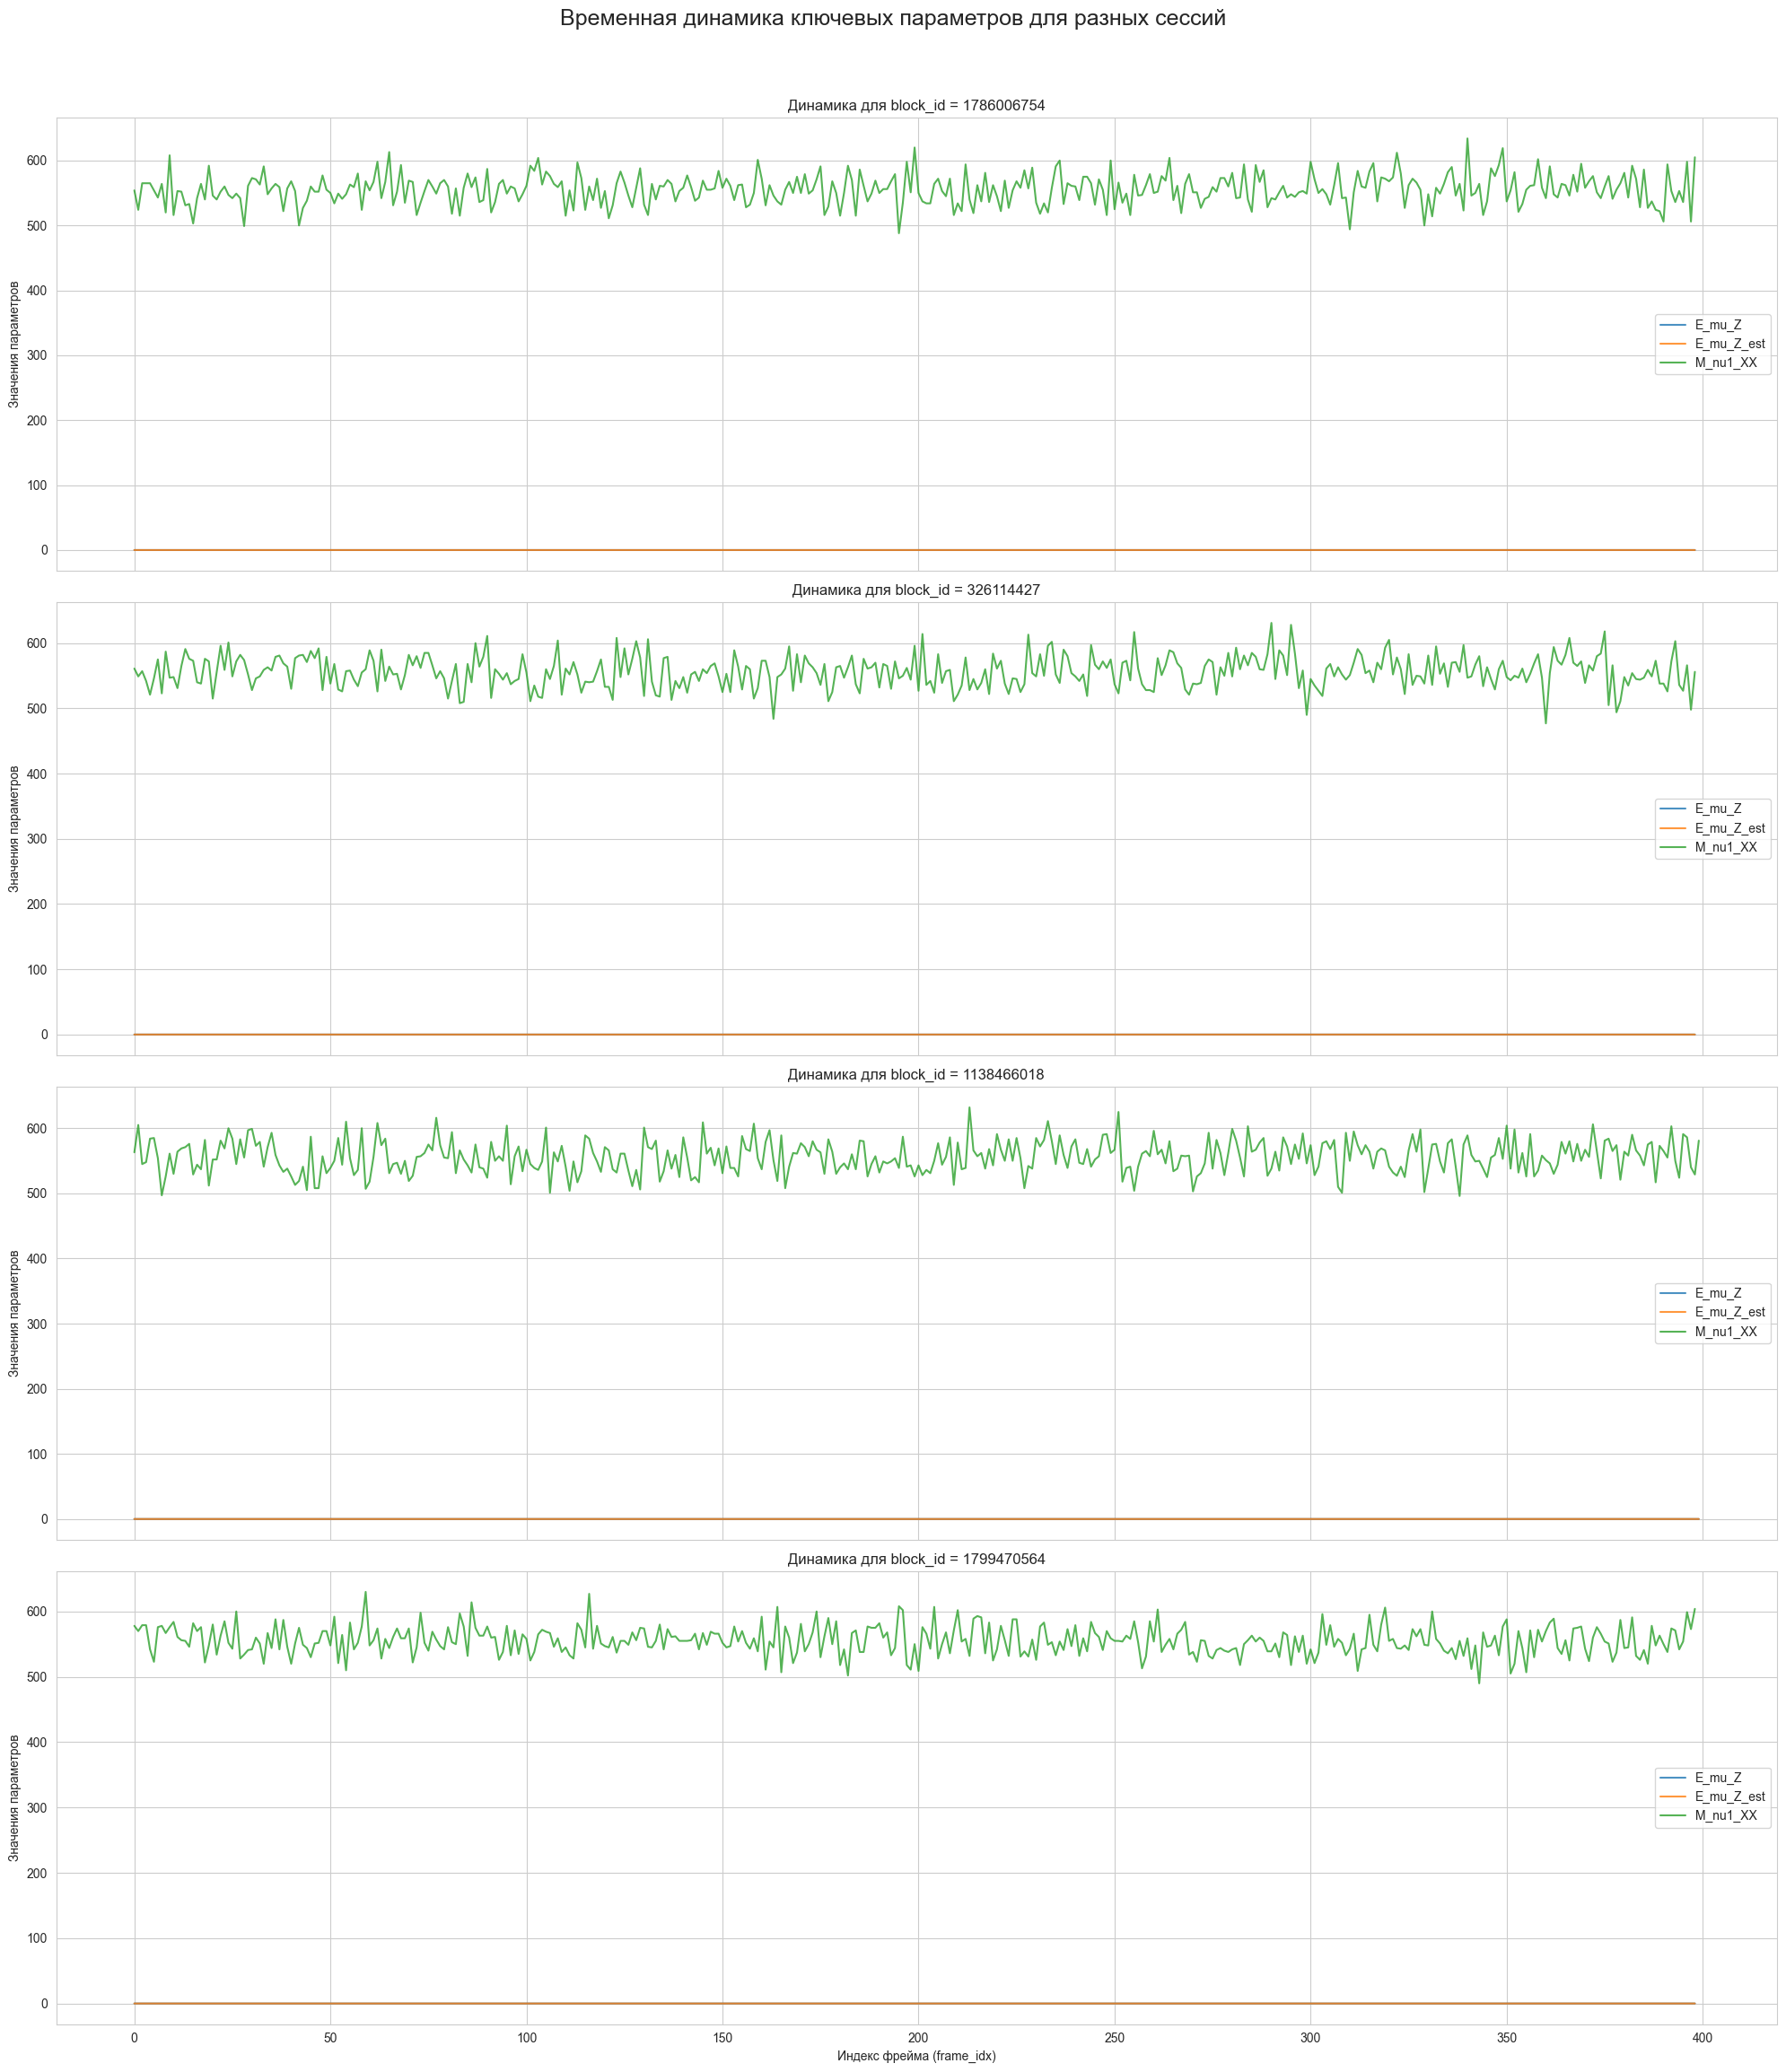

In [13]:
# ==============================================================================
# 4.1. Анализ динамики внутри сессий (block_id)
# ==============================================================================
print("--- Анализ временной динамики внутри нескольких случайных сессий ---")
    
# Получаем список уникальных block_id
all_block_ids = df['id'].unique()
    
# Выбираем 4 случайных ID для анализа, чтобы увидеть разнообразие
# np.random.choice обеспечивает, что мы не выйдем за пределы, если блоков мало
sample_ids = np.random.choice(all_block_ids, size=min(4, len(all_block_ids)), replace=False)
    
print(f"Выбраны случайные block_id для анализа: {sample_ids}")
    
# Признаки, которые мы хотим отслеживать во времени
# Наша цель, два главных предиктора и один "режимный" предиктор
features_to_plot = ['E_mu_Z', 'E_mu_Z_est', 'M_nu1_XX']
    
# Создаем сетку графиков
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(20, 6 * len(sample_ids)), sharex=True)
fig.suptitle('Временная динамика ключевых параметров для разных сессий', fontsize=18, y=0.99)

for i, block_id in enumerate(sample_ids):
    # Фильтруем данные для текущего block_id
    df_block = df[df['id'] == block_id].sort_values('date')
        
    ax = axes[i]
        
    # Строим графики для каждого признака
    for feature in features_to_plot:
        ax.plot(df_block['date'], df_block[feature], label=feature, alpha=0.8)
            
    ax.set_title(f'Динамика для block_id = {block_id}')
    ax.set_ylabel('Значения параметров')
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Индекс фрейма (frame_idx)')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


--- Сравнение распределения E_mu_Z между разными сессиями ---


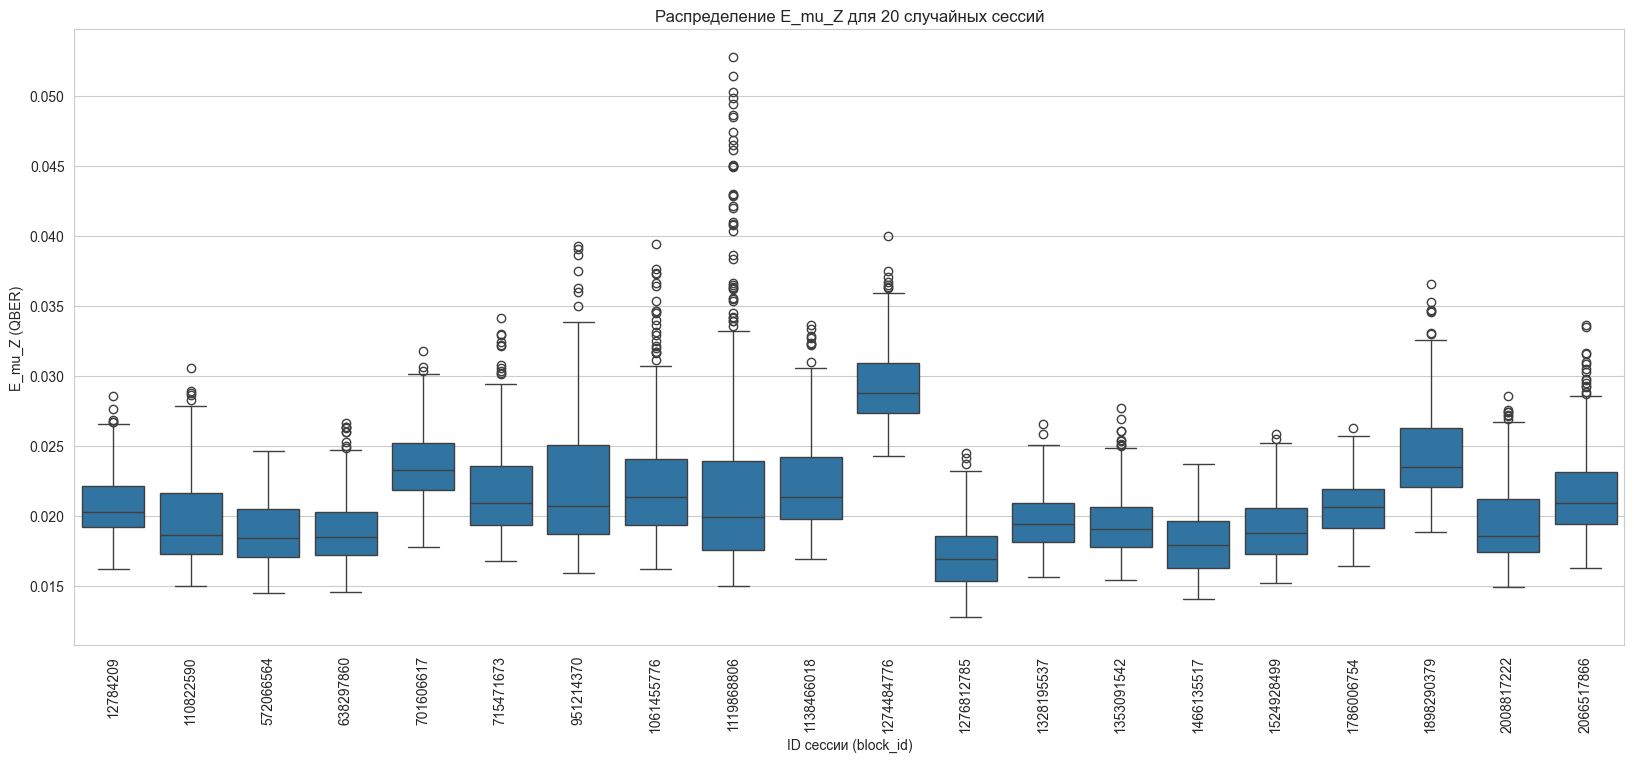

In [14]:
# ==============================================================================
# 4.2. Сравнение статистик между сессиями
# ==============================================================================
if df is not None:
    print("\n--- Сравнение распределения E_mu_Z между разными сессиями ---")
    
    # Возьмем больше случайных сессий для построения boxplot
    sample_ids_for_boxplot = np.random.choice(all_block_ids, size=min(20, len(all_block_ids)), replace=False)
    
    df_sample_blocks = df[df['id'].isin(sample_ids_for_boxplot)]
    
    plt.figure(figsize=(20, 8))
    sns.boxplot(data=df_sample_blocks, x='id', y='E_mu_Z')
    plt.title('Распределение E_mu_Z для 20 случайных сессий')
    plt.xlabel('ID сессии (block_id)')
    plt.ylabel('E_mu_Z (QBER)')
    plt.xticks(rotation=90)
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Анализ выбора скорости кода (R) в зависимости от E_mu_Z ---


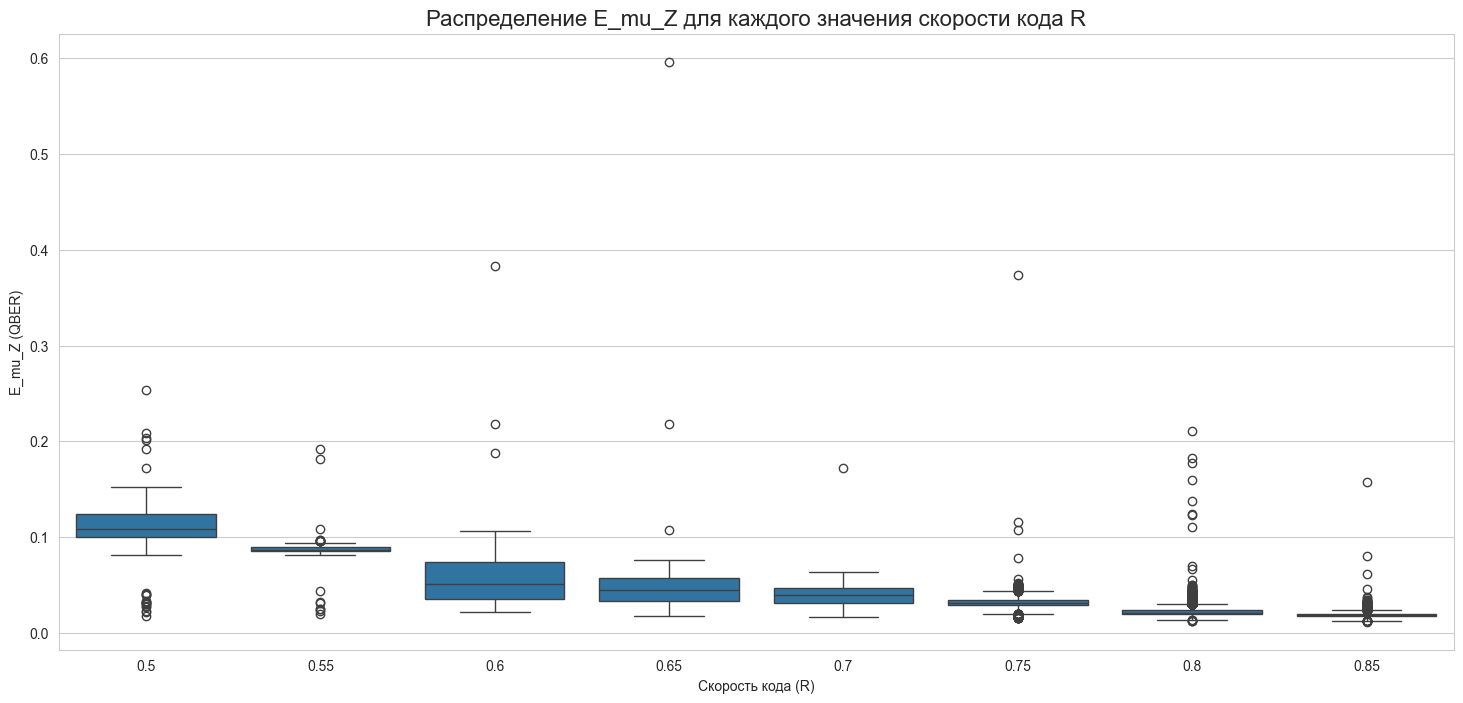

In [15]:
# ==============================================================================
# 5.1. Анализ зависимости выбора скорости кода (R) от уровня ошибок
# ==============================================================================
if df is not None:
    print("--- Анализ выбора скорости кода (R) в зависимости от E_mu_Z ---")
    
    # Сортируем значения R для более логичного отображения на графике
    sorted_r_values = sorted(df['R'].unique())
    
    plt.figure(figsize=(18, 8))
    sns.boxplot(data=df, x='R', y='E_mu_Z', order=sorted_r_values)
    plt.title('Распределение E_mu_Z для каждого значения скорости кода R', fontsize=16)
    plt.xlabel('Скорость кода (R)')
    plt.ylabel('E_mu_Z (QBER)')
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ выбора числа сокращенных узлов (s) в зависимости от E_mu_Z ---


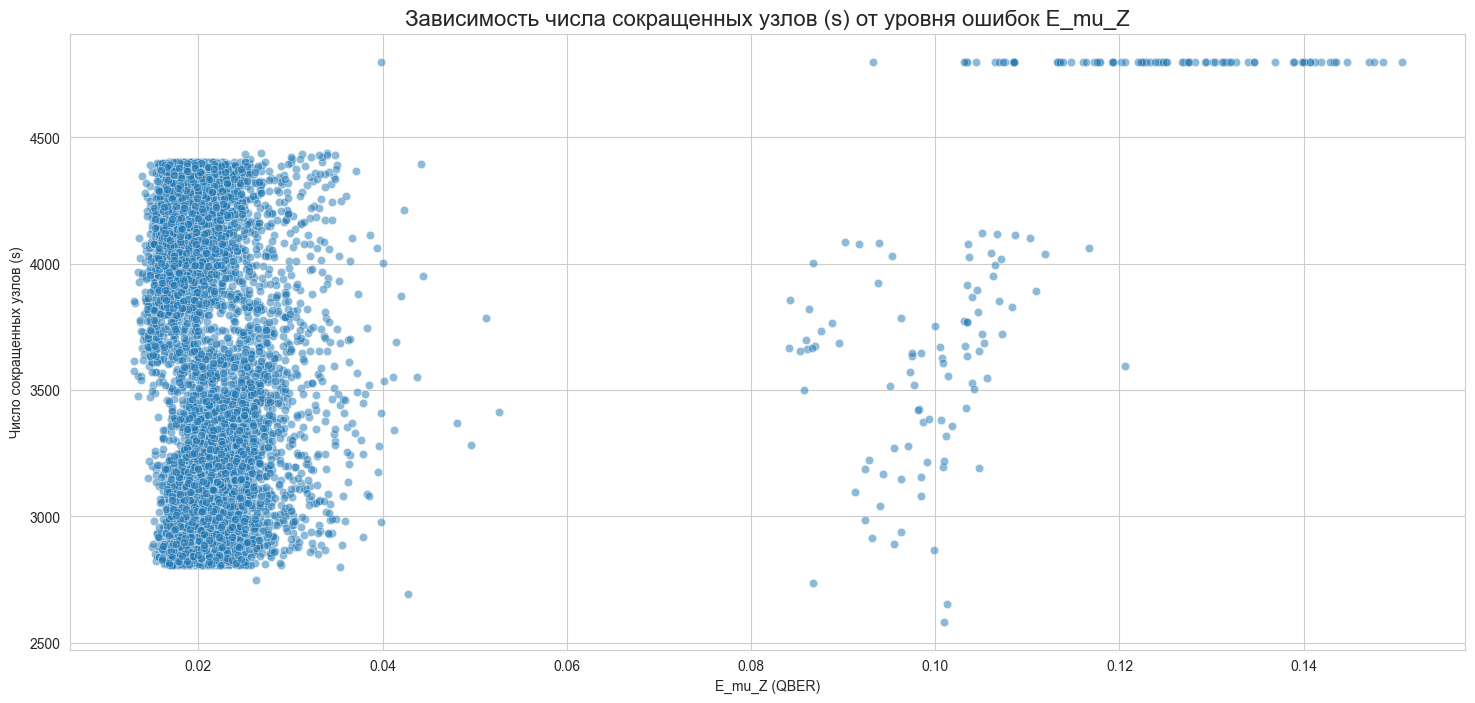

In [16]:
# ==============================================================================
# 5.2. Анализ зависимости выбора числа сокращенных узлов (s) от уровня ошибок
# ==============================================================================
if df is not None:
    print("\n--- Анализ выбора числа сокращенных узлов (s) в зависимости от E_mu_Z ---")
    
    # Используем случайную выборку для scatter plot, чтобы он был читаемым
    df_sample = df.sample(n=min(10000, len(df)), random_state=42)

    plt.figure(figsize=(18, 8))
    sns.scatterplot(data=df_sample, x='E_mu_Z', y='s', alpha=0.5)
    plt.title('Зависимость числа сокращенных узлов (s) от уровня ошибок E_mu_Z', fontsize=16)
    plt.xlabel('E_mu_Z (QBER)')
    plt.ylabel('Число сокращенных узлов (s)')
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Взаимосвязь между выбором R и s ---


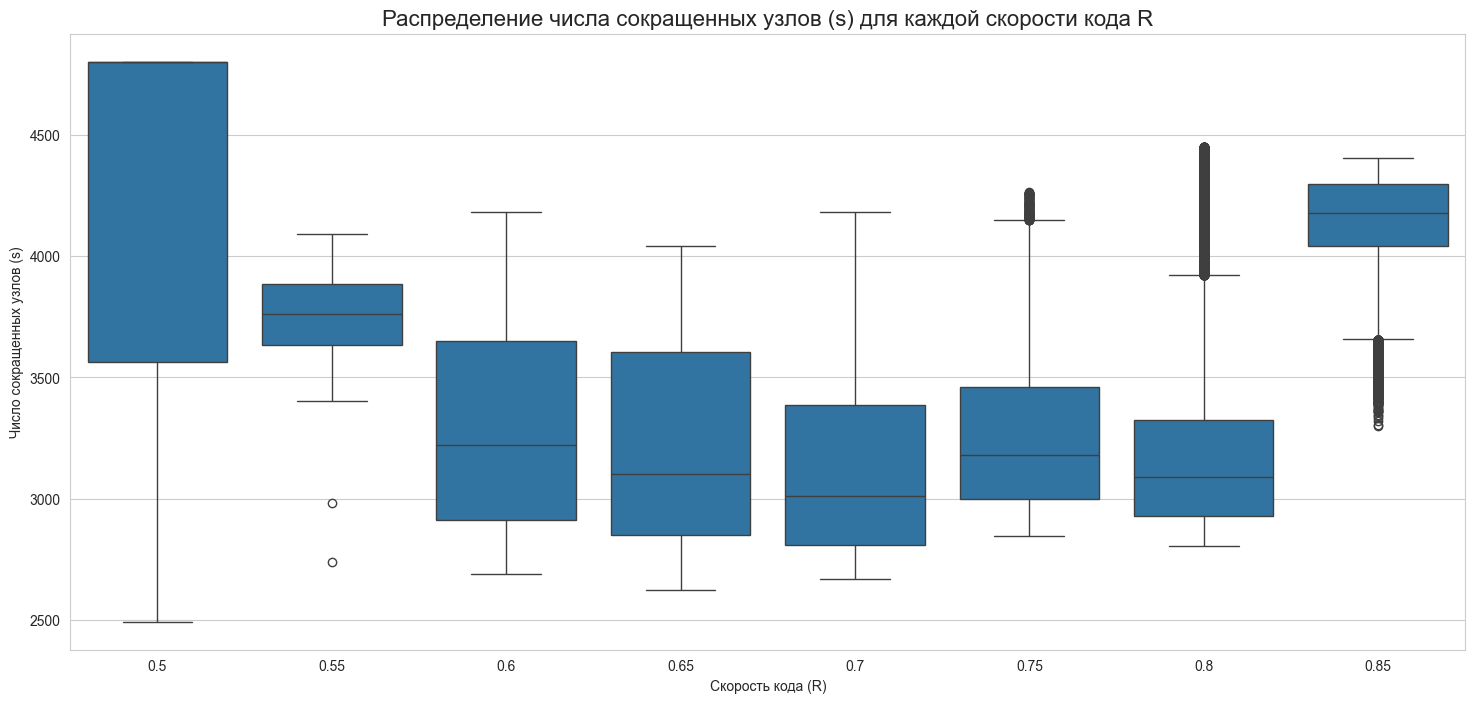

In [17]:
# ==============================================================================
# 5.3. Взаимосвязь между выбранными параметрами R и s
# ==============================================================================
if df is not None:
    print("\n--- Взаимосвязь между выбором R и s ---")

    plt.figure(figsize=(18, 8))
    sns.boxplot(data=df, x='R', y='s', order=sorted_r_values)
    plt.title('Распределение числа сокращенных узлов (s) для каждой скорости кода R', fontsize=16)
    plt.xlabel('Скорость кода (R)')
    plt.ylabel('Число сокращенных узлов (s)')
    plt.show()
    
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

Загрузка сырых данных...
  - Данные успешно загружены. Форма: (328617, 48)


C:\Users\iboro\AppData\Local\Temp\ipykernel_15980\656975866.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[TARGET_COLUMN], order=r_order, palette='viridis')


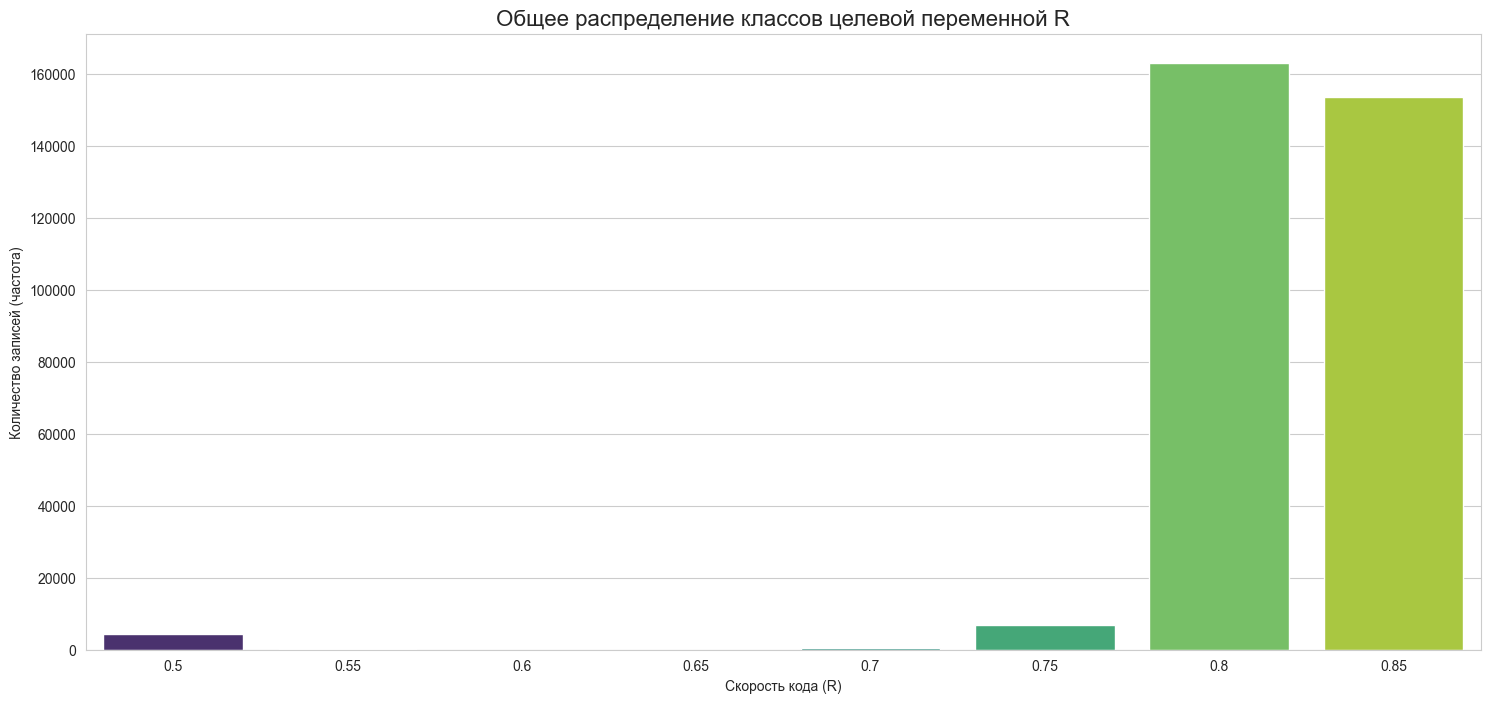


--- Точное количество записей для каждого класса ---
R
0.50      4435
0.55       336
0.60        18
0.65        59
0.70       385
0.75      6820
0.80    163065
0.85    153499
Name: count, dtype: int64


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Конфигурация ---
# Используем исходный, "сырой" датасет, т.к. для этого анализа нужны только 'R' и 'block_id'
RAW_DATA_PATH = '../data/raw/frames_errors.csv'
TARGET_COLUMN = 'R'

# --- Загрузка данных ---
print("Загрузка сырых данных...")
try:
    df = pd.read_csv(RAW_DATA_PATH)
    print(f"  - Данные успешно загружены. Форма: {df.shape}")
except FileNotFoundError:
    df = None
    print(f"Ошибка: Файл '{RAW_DATA_PATH}' не найден.")

# --- Анализ ---
if df is not None:
    # Сортируем значения R для логичного порядка на графике
    r_order = sorted(df[TARGET_COLUMN].unique())
    
    plt.figure(figsize=(18, 8))
    sns.countplot(x=df[TARGET_COLUMN], order=r_order, palette='viridis')
    
    plt.title('Общее распределение классов целевой переменной R', fontsize=16)
    plt.xlabel('Скорость кода (R)')
    plt.ylabel('Количество записей (частота)')
    plt.show()

    print("\n--- Точное количество записей для каждого класса ---")
    print(df[TARGET_COLUMN].value_counts().sort_index())

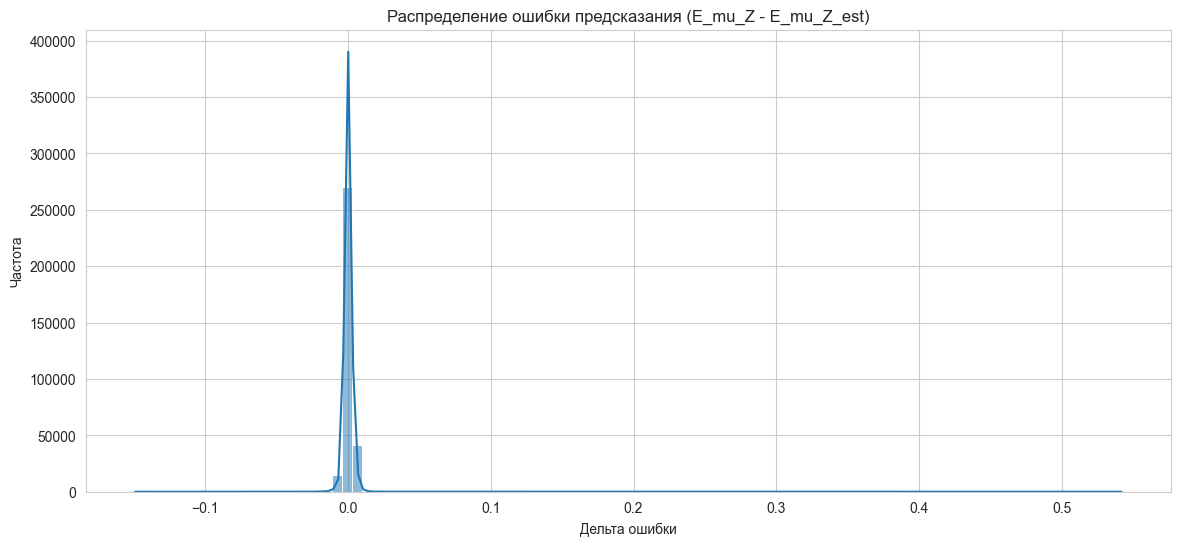

Статистики по ошибке предсказания:
count    328617.00000
mean         -0.00001
std           0.00333
min          -0.14917
25%          -0.00162
50%          -0.00018
75%           0.00151
max           0.54182
Name: error_delta, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем колонку с ошибкой предсказания E_mu_Z_est
df['error_delta'] = df['E_mu_Z'] - df['E_mu_Z_est']

# Визуализируем распределение этой ошибки
plt.figure(figsize=(14, 6))
sns.histplot(df['error_delta'], bins=100, kde=True)
plt.title('Распределение ошибки предсказания (E_mu_Z - E_mu_Z_est)')
plt.xlabel('Дельта ошибки')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

print("Статистики по ошибке предсказания:")
print(df['error_delta'].describe())

0:	learn: 0.0106391	total: 81.9ms	remaining: 40.9s
100:	learn: 0.0011988	total: 704ms	remaining: 2.78s
200:	learn: 0.0010498	total: 1.33s	remaining: 1.97s
300:	learn: 0.0009928	total: 1.98s	remaining: 1.31s
400:	learn: 0.0009549	total: 2.6s	remaining: 643ms
499:	learn: 0.0009227	total: 3.23s	remaining: 0us


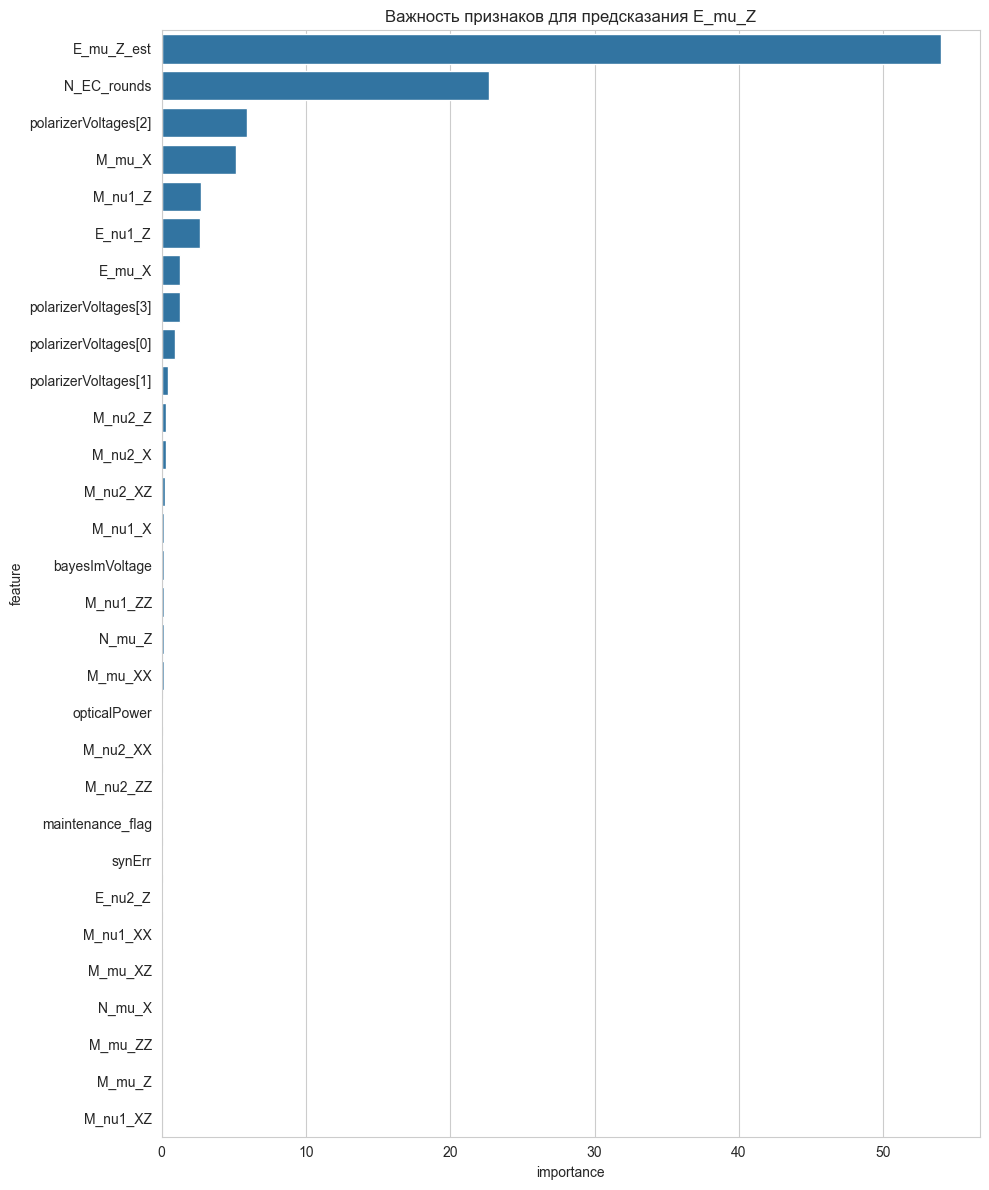

In [5]:
from catboost import CatBoostRegressor
import pandas as pd

# Определяем признаки и цель
features = [col for col in df.columns if col not in ['id', 'date', 'E_mu_Z', 'R', 's', 'p', 'error_delta', 'estimator_name']]
# Убедимся, что все признаки числовые
X = df[features].select_dtypes(include=np.number)
y = df['E_mu_Z']

# Обучаем быструю модель
model_emuz = CatBoostRegressor(iterations=500,
                             learning_rate=0.1,
                             depth=7,
                             verbose=100,
                             task_type="GPU",
                             random_seed=42)

model_emuz.fit(X, y)

# Получаем и визуализируем важность признаков
feature_importance_df = pd.DataFrame({'feature': X.columns, 'importance': model_emuz.get_feature_importance()})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(30))
plt.title('Важность признаков для предсказания E_mu_Z')
plt.tight_layout()
plt.show()

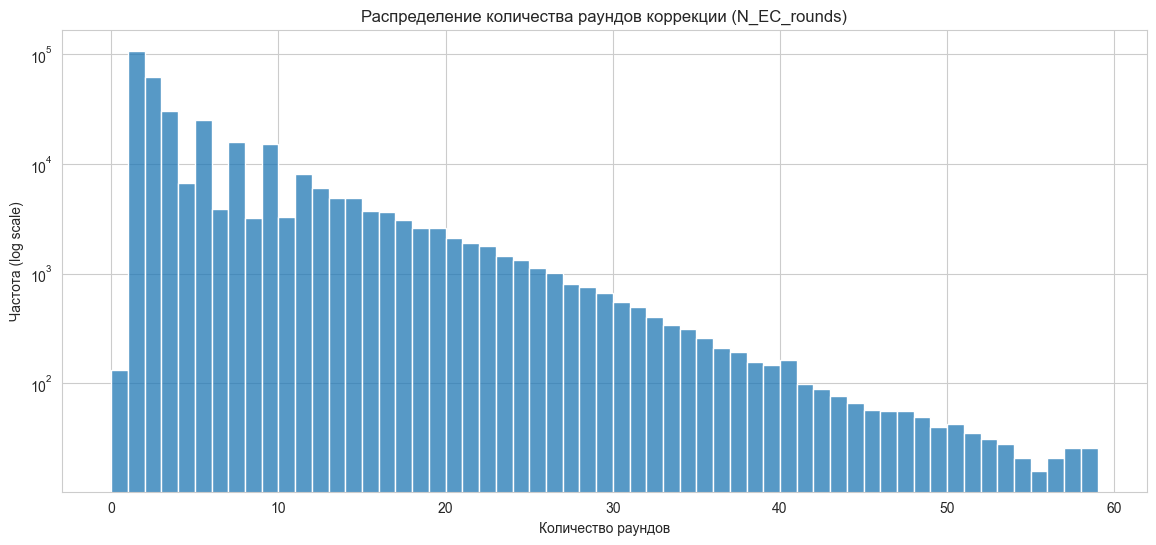

Наиболее частые значения N_EC_rounds:
N_EC_rounds
1     107143
2      61476
3      30132
5      25259
7      15846
9      15092
11      8144
4       6648
12      5969
14      4899
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(14, 6))
sns.histplot(df['N_EC_rounds'], bins=df['N_EC_rounds'].max(), kde=False)
plt.title('Распределение количества раундов коррекции (N_EC_rounds)')
plt.xlabel('Количество раундов')
plt.yscale('log') # Используем логарифмическую шкалу, чтобы увидеть хвост
plt.ylabel('Частота (log scale)')
plt.grid(True)
plt.show()

print("Наиболее частые значения N_EC_rounds:")
print(df['N_EC_rounds'].value_counts().head(10))

C:\Users\iboro\AppData\Local\Temp\ipykernel_21084\3341433318.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = df.groupby(['R', s_bins])['N_EC_rounds'].mean().reset_index()
C:\Users\iboro\AppData\Local\Temp\ipykernel_21084\3341433318.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_final = pivot_table.pivot_table(index='R', columns='s', values='N_EC_rounds')


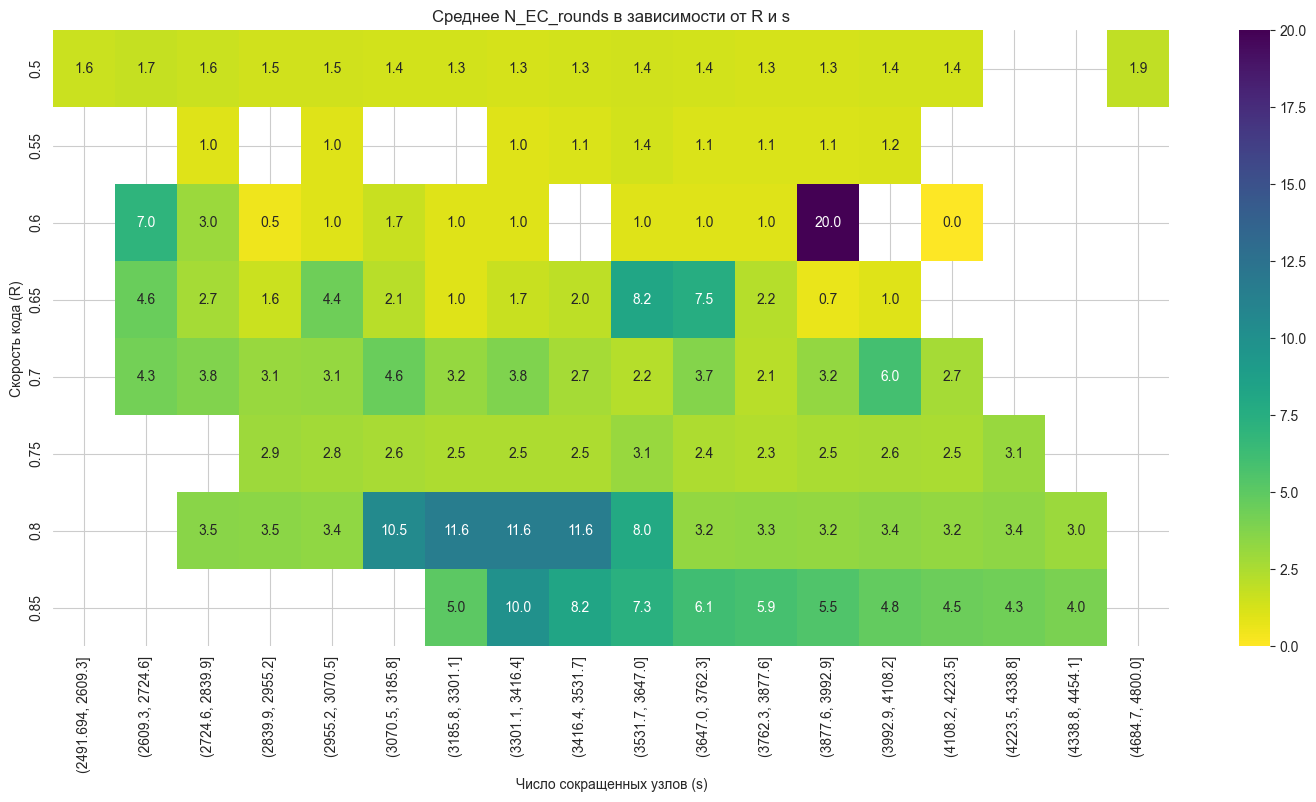

In [7]:
# Создаем сводную таблицу: среднее N_EC_rounds для каждой пары (R, s)
# Так как s - непрерывная переменная, сгруппируем ее в бины
s_bins = pd.cut(df['s'], bins=20) # 20 бинов для наглядности
pivot_table = df.groupby(['R', s_bins])['N_EC_rounds'].mean().reset_index()
pivot_table_final = pivot_table.pivot_table(index='R', columns='s', values='N_EC_rounds')

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_table_final, annot=True, fmt=".1f", cmap="viridis_r") # _r инвертирует палитру, зеленый - хорошо
plt.title('Среднее N_EC_rounds в зависимости от R и s')
plt.xlabel('Число сокращенных узлов (s)')
plt.ylabel('Скорость кода (R)')
plt.show()

0:	learn: 6.1987192	total: 12.2ms	remaining: 6.09s
100:	learn: 1.1099821	total: 632ms	remaining: 2.5s
200:	learn: 1.0443199	total: 1.27s	remaining: 1.9s
300:	learn: 1.0260352	total: 1.95s	remaining: 1.29s
400:	learn: 1.0150336	total: 2.6s	remaining: 641ms
499:	learn: 1.0064769	total: 3.27s	remaining: 0us


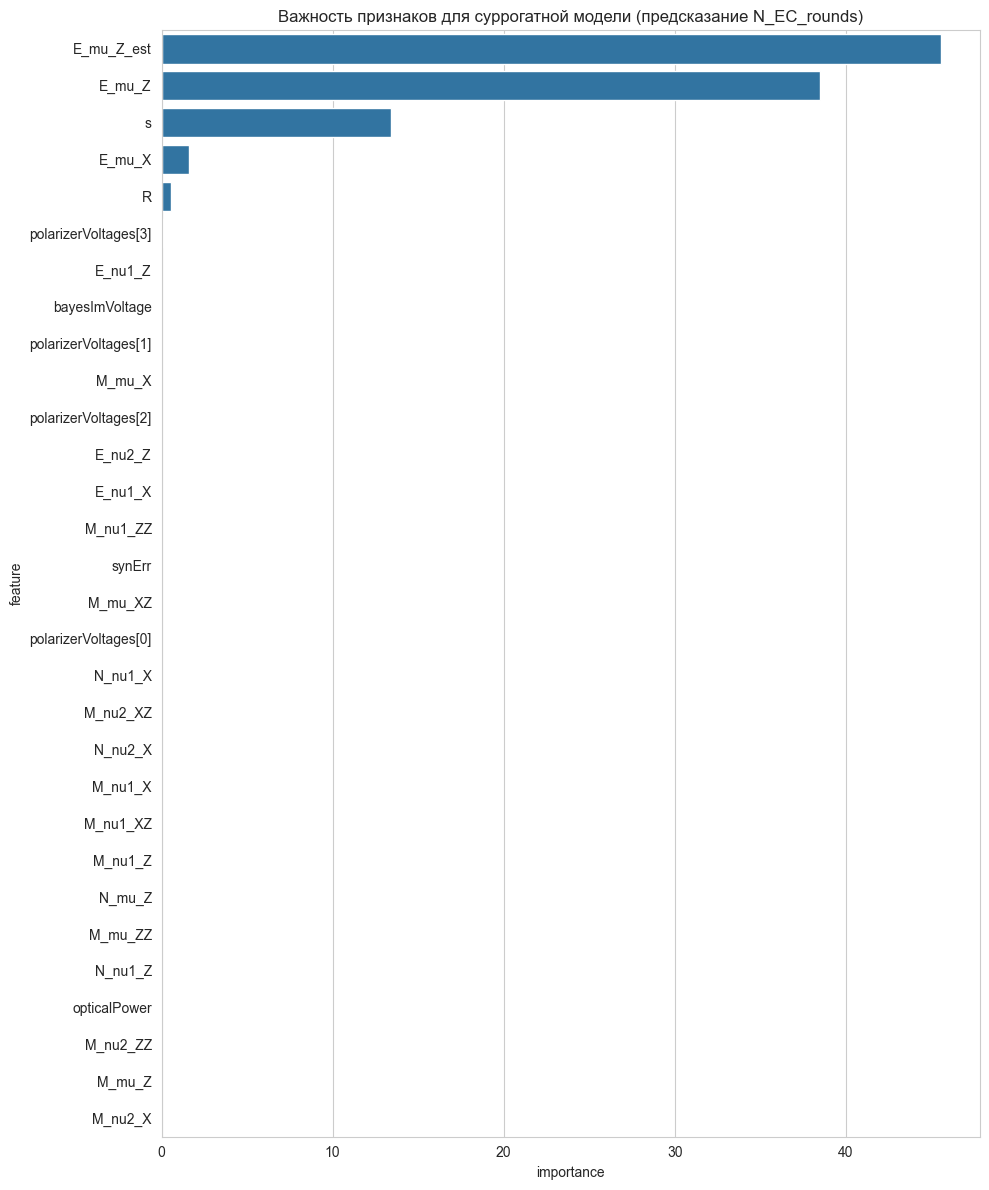

In [8]:
# Определяем признаки и цель для суррогатной модели
features_surrogate = [col for col in df.columns if col not in ['id', 'date', 'p', 'error_delta', 'estimator_name']]
X_surrogate = df[features_surrogate].select_dtypes(include=np.number).drop(columns=['N_EC_rounds'])
y_surrogate = df['N_EC_rounds']

# Обучаем быструю модель
model_surrogate = CatBoostRegressor(iterations=500,
                                    learning_rate=0.1,
                                    depth=7,
                                    verbose=100,
                                    task_type="GPU",
                                    random_seed=42,
                                    loss_function='RMSE')

model_surrogate.fit(X_surrogate, y_surrogate)

# Получаем и визуализируем важность признаков
feature_importance_surrogate_df = pd.DataFrame({'feature': X_surrogate.columns, 'importance': model_surrogate.get_feature_importance()})
feature_importance_surrogate_df = feature_importance_surrogate_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='importance', y='feature', data=feature_importance_surrogate_df.head(30))
plt.title('Важность признаков для суррогатной модели (предсказание N_EC_rounds)')
plt.tight_layout()
plt.show()

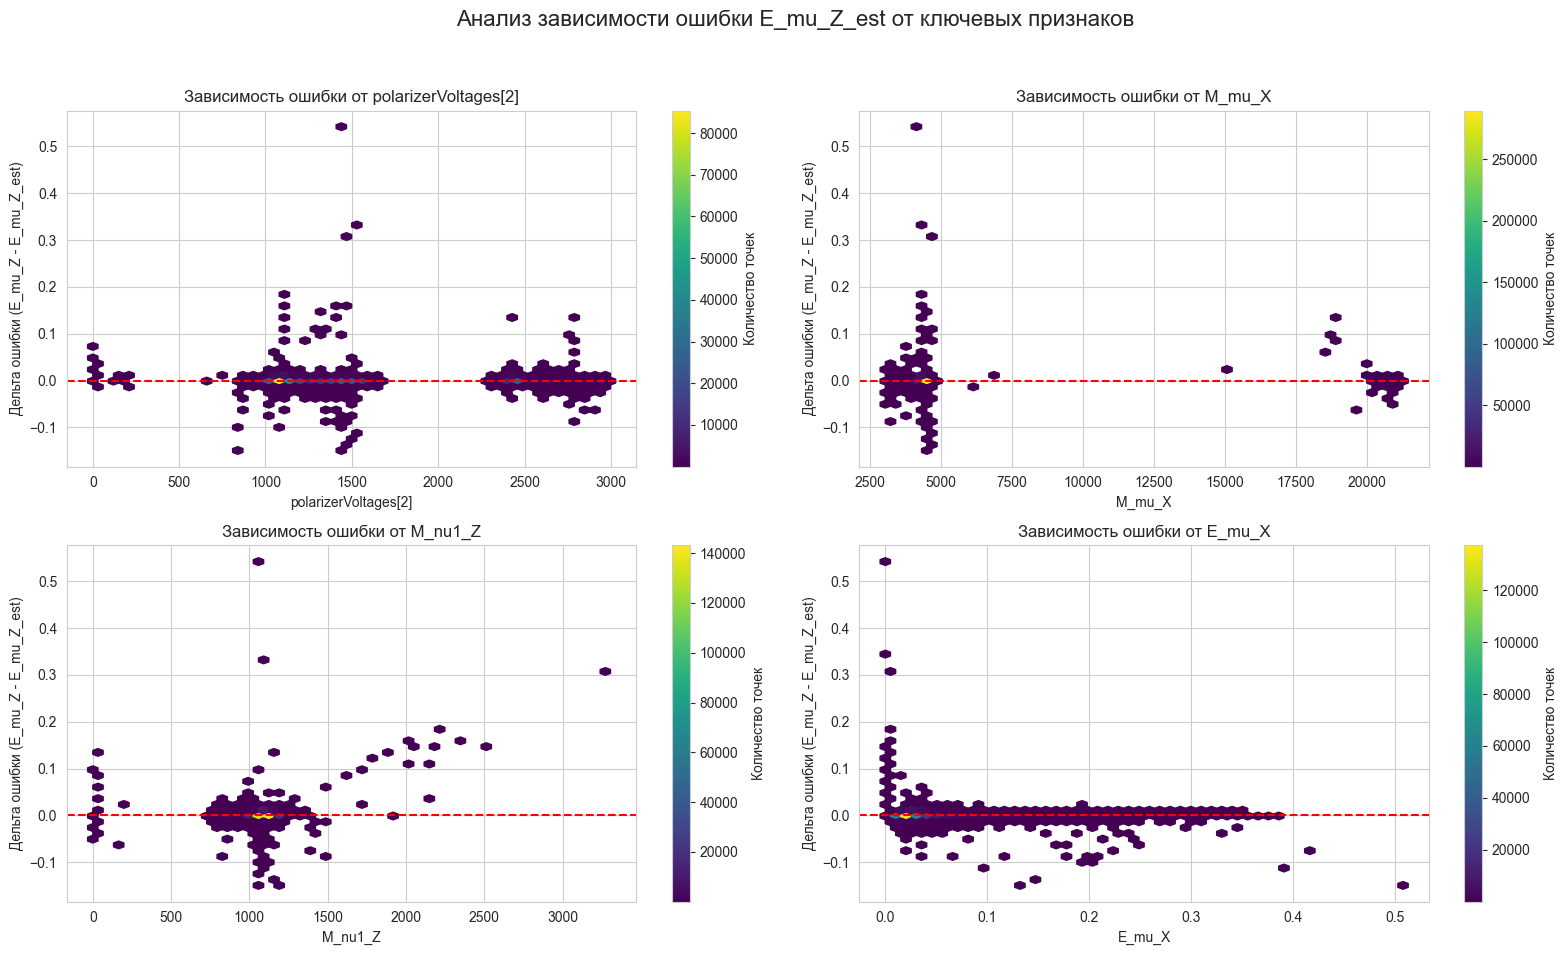

In [9]:
import numpy as np

# Возьмем топ-4 корректирующих признака из предыдущего анализа
# Исключаем N_EC_rounds из-за таргет-лика
correcting_features = ['polarizerVoltages[2]', 'M_mu_X', 'M_nu1_Z', 'E_mu_X']

plt.figure(figsize=(16, 10))
plt.suptitle('Анализ зависимости ошибки E_mu_Z_est от ключевых признаков', fontsize=16)

for i, feature in enumerate(correcting_features):
    plt.subplot(2, 2, i + 1)
    # Используем hexbin plot для визуализации плотности в местах с большим количеством точек
    plt.hexbin(df[feature], df['error_delta'], gridsize=50, cmap='viridis', mincnt=1)
    plt.colorbar(label='Количество точек')
    plt.xlabel(feature)
    plt.ylabel('Дельта ошибки (E_mu_Z - E_mu_Z_est)')
    plt.title(f'Зависимость ошибки от {feature}')
    plt.axhline(0, color='red', linestyle='--') # Линия нулевой ошибки

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Медиана E_mu_Z: 0.0199
Размер выборки с низким шумом: 164079
Размер выборки с высоким шумом: 164538


C:\Users\iboro\AppData\Local\Temp\ipykernel_21084\1791181345.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby(['R', s_bins])['N_EC_rounds'].mean().reset_index()
C:\Users\iboro\AppData\Local\Temp\ipykernel_21084\1791181345.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_final = pivot_table.pivot_table(index='R', columns='s', values='N_EC_rounds')


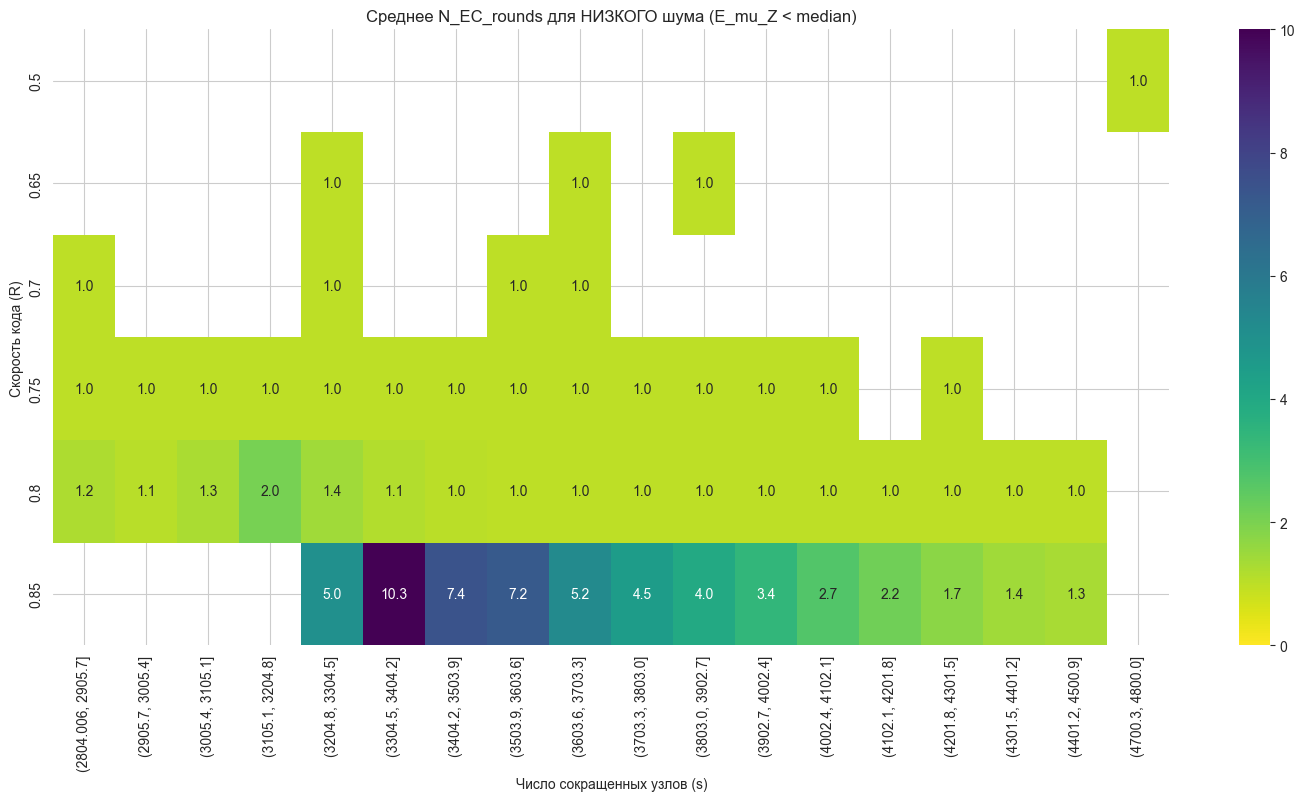

C:\Users\iboro\AppData\Local\Temp\ipykernel_21084\1791181345.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby(['R', s_bins])['N_EC_rounds'].mean().reset_index()
C:\Users\iboro\AppData\Local\Temp\ipykernel_21084\1791181345.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_final = pivot_table.pivot_table(index='R', columns='s', values='N_EC_rounds')


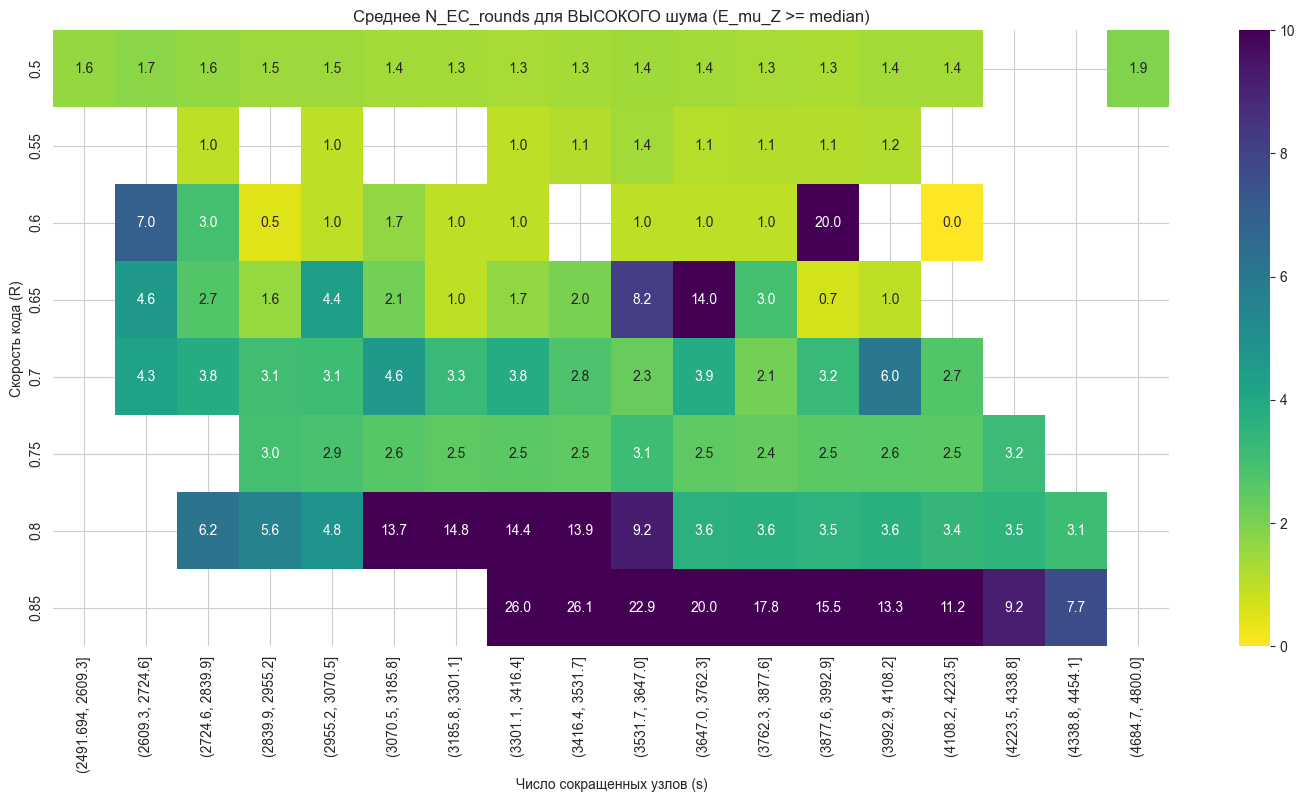

In [10]:
# Разделим датасет на две части по медианному значению E_mu_Z
median_emuz = df['E_mu_Z'].median()
df_low_noise = df[df['E_mu_Z'] < median_emuz]
df_high_noise = df[df['E_mu_Z'] >= median_emuz]

print(f"Медиана E_mu_Z: {median_emuz:.4f}")
print(f"Размер выборки с низким шумом: {len(df_low_noise)}")
print(f"Размер выборки с высоким шумом: {len(df_high_noise)}")

# Функция для построения тепловой карты
def plot_heatmap(dataframe, title):
    s_bins = pd.cut(dataframe['s'], bins=20)
    pivot_table = dataframe.groupby(['R', s_bins])['N_EC_rounds'].mean().reset_index()
    pivot_table_final = pivot_table.pivot_table(index='R', columns='s', values='N_EC_rounds')
    
    plt.figure(figsize=(18, 8))
    sns.heatmap(pivot_table_final, annot=True, fmt=".1f", cmap="viridis_r", vmin=0, vmax=10) # Фиксируем шкалу для сравнения
    plt.title(title)
    plt.xlabel('Число сокращенных узлов (s)')
    plt.ylabel('Скорость кода (R)')
    plt.show()

# Строим карты
plot_heatmap(df_low_noise, 'Среднее N_EC_rounds для НИЗКОГО шума (E_mu_Z < median)')
plot_heatmap(df_high_noise, 'Среднее N_EC_rounds для ВЫСОКОГО шума (E_mu_Z >= median)')

Среднее N_EC_rounds: 5.50
Дисперсия N_EC_rounds: 45.35

Дисперсия значительно больше среднего. Это называется 'сверхдисперсия' (overdispersion).
В этом случае логарифмирование таргета (np.log1p) или использование TweedieRegressor/NegativeBinomial loss может быть эффективнее, чем стандартный RMSE или Poisson loss.


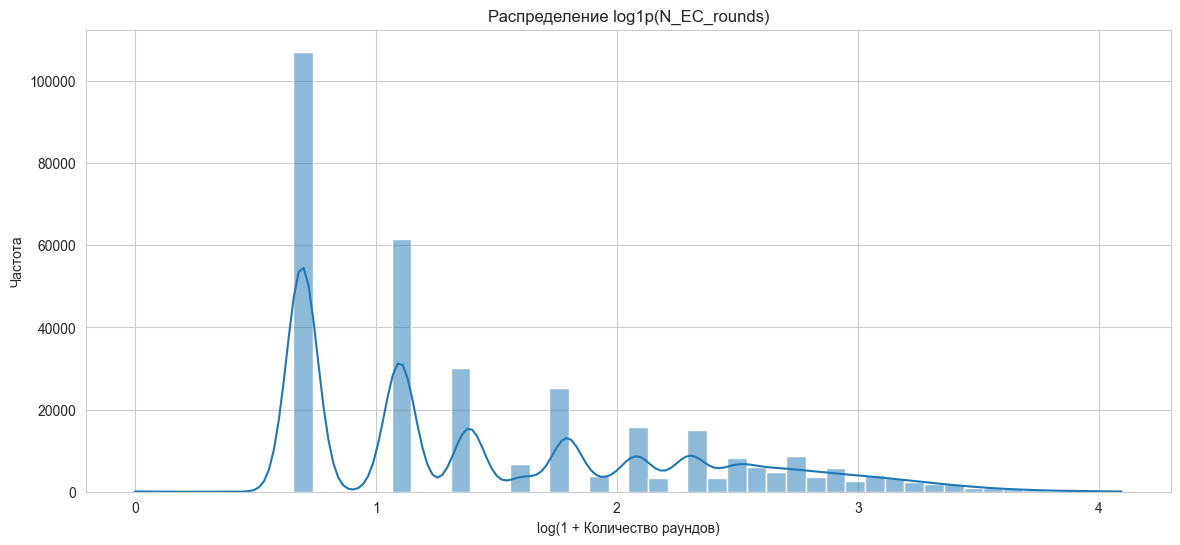

In [11]:
# Сравним среднее и дисперсию N_EC_rounds
mean_rounds = df['N_EC_rounds'].mean()
var_rounds = df['N_EC_rounds'].var()

print(f"Среднее N_EC_rounds: {mean_rounds:.2f}")
print(f"Дисперсия N_EC_rounds: {var_rounds:.2f}")

if var_rounds > mean_rounds:
    print("\nДисперсия значительно больше среднего. Это называется 'сверхдисперсия' (overdispersion).")
    print("В этом случае логарифмирование таргета (np.log1p) или использование TweedieRegressor/NegativeBinomial loss может быть эффективнее, чем стандартный RMSE или Poisson loss.")
else:
    print("\nДисперсия близка к среднему. Poisson loss может быть хорошим кандидатом.")

# Визуализация log1p(N_EC_rounds)
plt.figure(figsize=(14, 6))
sns.histplot(np.log1p(df['N_EC_rounds']), bins=50, kde=True)
plt.title('Распределение log1p(N_EC_rounds)')
plt.xlabel('log(1 + Количество раундов)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

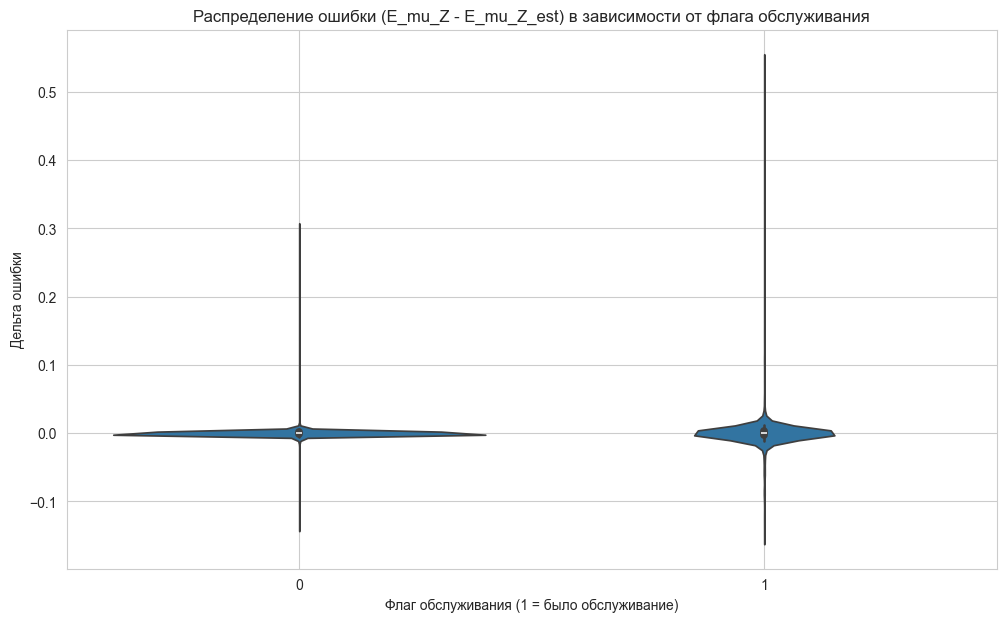

Статистики ошибки по флагу обслуживания:
                     count      mean       std      min       25%       50%  \
maintenance_flag                                                              
0                 327703.0 -0.000010  0.003027 -0.14310 -0.001610 -0.000180   
1                    914.0  0.000244  0.026499 -0.14917 -0.002905 -0.000285   

                      75%      max  
maintenance_flag                    
0                 0.00150  0.30720  
1                 0.00297  0.54182  


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.violinplot(x='maintenance_flag', y='error_delta', data=df)
plt.title('Распределение ошибки (E_mu_Z - E_mu_Z_est) в зависимости от флага обслуживания')
plt.xlabel('Флаг обслуживания (1 = было обслуживание)')
plt.ylabel('Дельта ошибки')
plt.grid(True)
plt.show()

print("Статистики ошибки по флагу обслуживания:")
print(df.groupby('maintenance_flag')['error_delta'].describe())

Размеры полученных кластеров:
physical_cluster
0    209422
1     73801
3     45343
2        51
Name: count, dtype: int64


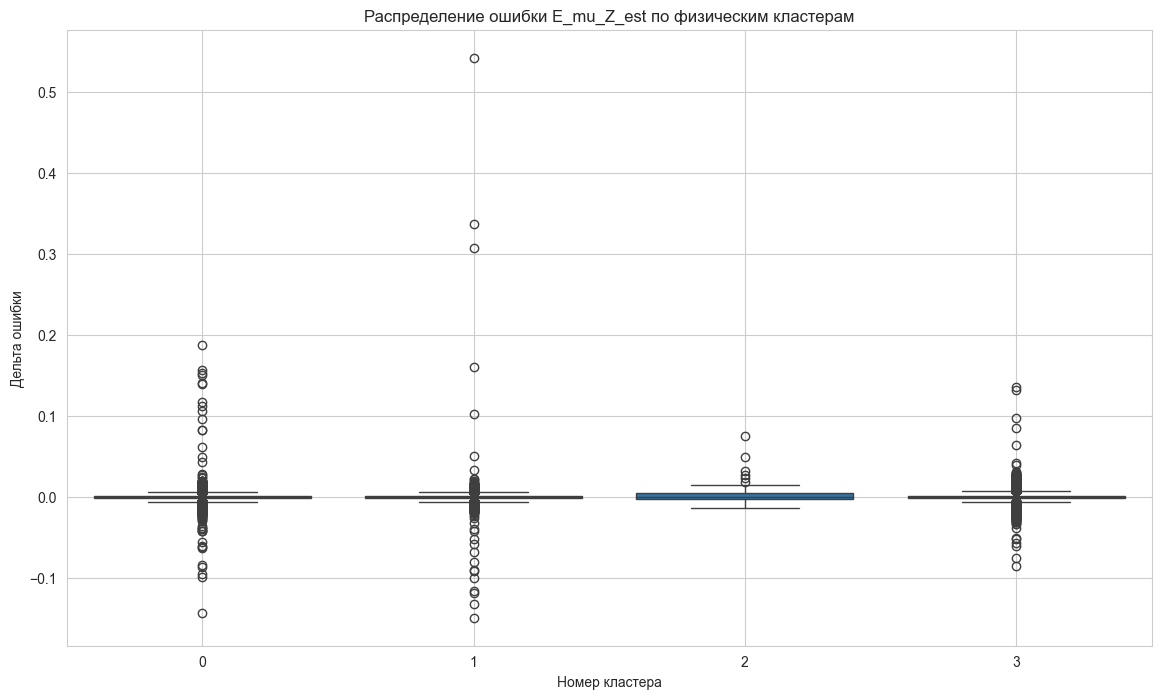

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Выбираем признаки, описывающие физическое состояние системы
physical_features = [
    'polarizerVoltages[0]', 'polarizerVoltages[1]', 'polarizerVoltages[2]', 'polarizerVoltages[3]',
    'temp_1', 'biasVoltage_1', 'temp_2', 'biasVoltage_2', 'opticalPower'
]

# Стандартизируем данные, так как K-Means чувствителен к масштабу
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[physical_features].fillna(0))

# Обучаем модель K-Means. Начнем с 4 кластеров для простоты.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['physical_cluster'] = kmeans.fit_predict(X_scaled)

print("Размеры полученных кластеров:")
print(df['physical_cluster'].value_counts())

# Визуализируем, как ошибка E_mu_Z_est распределена по этим кластерам
plt.figure(figsize=(14, 8))
sns.boxplot(x='physical_cluster', y='error_delta', data=df)
plt.title('Распределение ошибки E_mu_Z_est по физическим кластерам')
plt.xlabel('Номер кластера')
plt.ylabel('Дельта ошибки')
plt.grid(True)
plt.show()

In [14]:
# Определяем порог "провала". Возьмем топ 1% самых сложных случаев.
failure_threshold = df['N_EC_rounds'].quantile(0.99)
print(f"Порог для 'провальных' случаев (99-й перцентиль N_EC_rounds): {failure_threshold}")

df_failure = df[df['N_EC_rounds'] >= failure_threshold]
df_normal = df[df['N_EC_rounds'] < failure_threshold]

# Сравниваем статистики для двух групп
failure_stats = df_failure.describe().T
normal_stats = df_normal.describe().T

comparison_df = pd.DataFrame({
    'mean_failure': failure_stats['mean'],
    'mean_normal': normal_stats['mean'],
    'std_failure': failure_stats['std'],
    'std_normal': normal_stats['std']
})
comparison_df['mean_diff_ratio'] = (comparison_df['mean_failure'] - comparison_df['mean_normal']) / comparison_df['mean_normal']

# Выводим признаки с наибольшей разницей в средних
print("\nТоп-15 признаков, отличающих 'провальные' случаи (по относительной разнице средних):")
print(comparison_df.sort_values(by='mean_diff_ratio', ascending=False).head(15))

Порог для 'провальных' случаев (99-й перцентиль N_EC_rounds): 31.0

Топ-15 признаков, отличающих 'провальные' случаи (по относительной разнице средних):
                      mean_failure   mean_normal   std_failure    std_normal  \
N_EC_rounds           3.736878e+01  5.159329e+00  6.401140e+00  5.856448e+00   
maintenance_flag      7.961331e-03  2.725315e-03  8.888304e-02  5.213345e-02   
E_mu_Z                2.896824e-02  2.186030e-02  2.710060e-03  1.176497e-02   
E_mu_X                3.763824e-02  3.015220e-02  2.238694e-02  3.074726e-02   
p                     1.408411e+03  1.145798e+03  3.042158e+02  5.632190e+02   
E_nu1_Z               5.187097e-02  4.520371e-02  8.349203e-03  9.162946e-03   
E_nu1_X               6.133570e-02  5.376693e-02  6.019723e-02  5.916231e-02   
polarizerVoltages[1]  2.254512e+03  2.142167e+03  5.801860e+02  6.397018e+02   
N_mu_X                5.907992e+06  5.794618e+06  2.129716e+06  1.432950e+06   
M_nu1_XZ              1.370222e+02  1.343953e+0

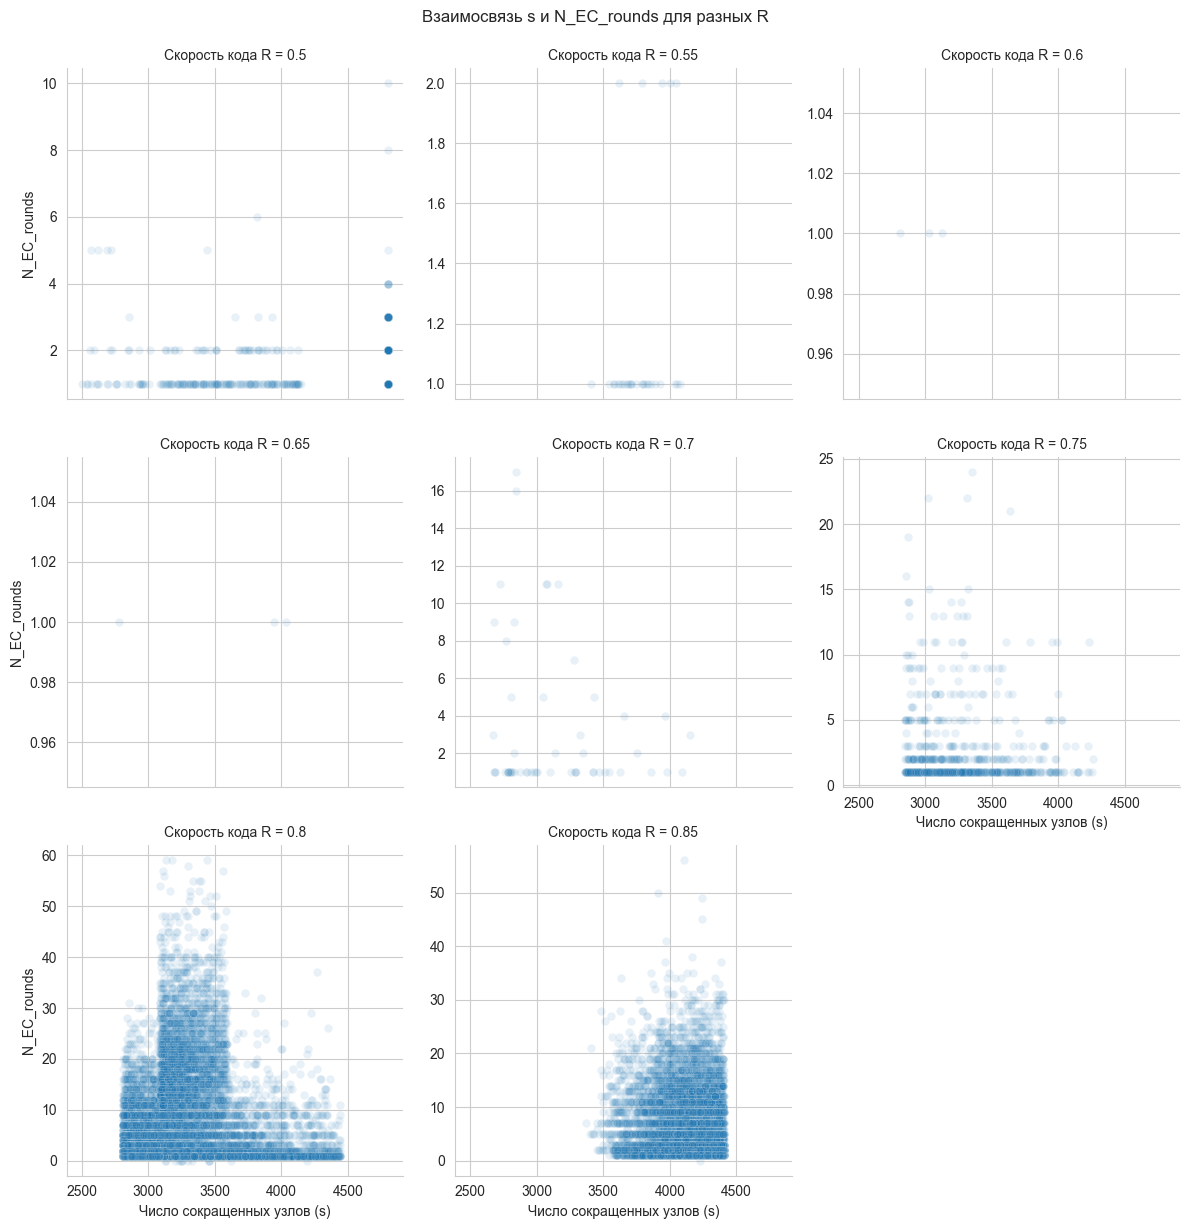

In [15]:
# R - категориальная переменная, поэтому FacetGrid подходит идеально.
g = sns.FacetGrid(df.sample(frac=0.1), col="R", col_wrap=3, height=4, sharey=False)

# Используем scatter plot с низкой прозрачностью, чтобы видеть плотность
g.map(sns.scatterplot, "s", "N_EC_rounds", alpha=0.1)
g.set_titles("Скорость кода R = {col_name}")
g.set_axis_labels("Число сокращенных узлов (s)", "N_EC_rounds")
plt.suptitle('Взаимосвязь s и N_EC_rounds для разных R', y=1.02)
plt.show()

C:\Users\iboro\AppData\Local\Temp\ipykernel_21084\3127100294.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(cluster_profiles_normalized.index))


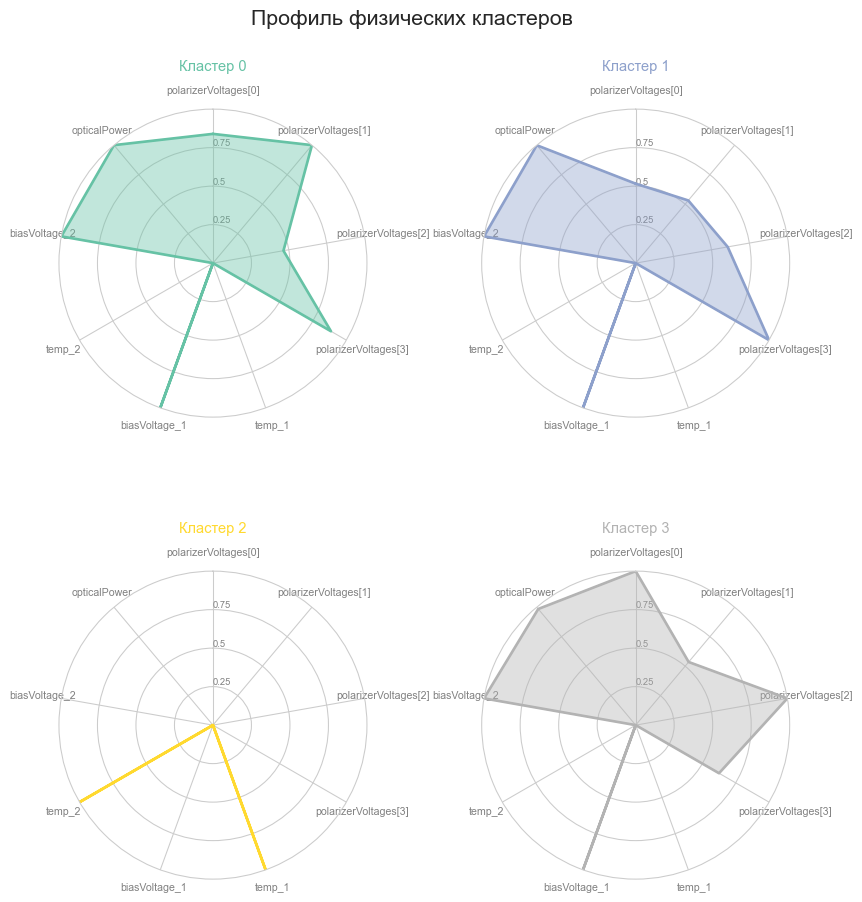

In [16]:
# Для наглядного сравнения нескольких параметров между кластерами идеально подходит радарная диаграмма
from math import pi
import matplotlib.pyplot as plt

# Берем те же физические признаки, по которым кластеризовали
physical_features = [
    'polarizerVoltages[0]', 'polarizerVoltages[1]', 'polarizerVoltages[2]', 'polarizerVoltages[3]',
    'temp_1', 'biasVoltage_1', 'temp_2', 'biasVoltage_2', 'opticalPower'
]

# Считаем средние значения для каждого кластера и нормализуем их для сравнения на одном графике
cluster_profiles = df.groupby('physical_cluster')[physical_features].mean()
cluster_profiles_normalized = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())
cluster_profiles_normalized = cluster_profiles_normalized.reset_index()

# Функция для радарной диаграммы
def make_radar_chart(row, title, color, D, N):
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax = plt.subplot(2,2,row+1, polar=True)
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], D, color='grey', size=8)
    ax.set_rlabel_position(0)
    plt.yticks([0.25,0.5,0.75], ["0.25","0.5","0.75"], color="grey", size=7)
    plt.ylim(0,1)
    
    values = cluster_profiles_normalized.loc[row].drop('physical_cluster').values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)
    plt.title(title, size=11, color=color, y=1.1)

# --- Построение ---
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
plt.subplots_adjust(hspace=0.5)

# Создаем палитру
my_palette = plt.cm.get_cmap("Set2", len(cluster_profiles_normalized.index))

for row in range(0, len(cluster_profiles_normalized.index)):
    make_radar_chart(row=row, title='Кластер ' + str(cluster_profiles_normalized['physical_cluster'][row]), 
                     color=my_palette(row), D=physical_features, N=len(physical_features))

plt.suptitle("Профиль физических кластеров", fontsize=16, y=0.98)
plt.show()

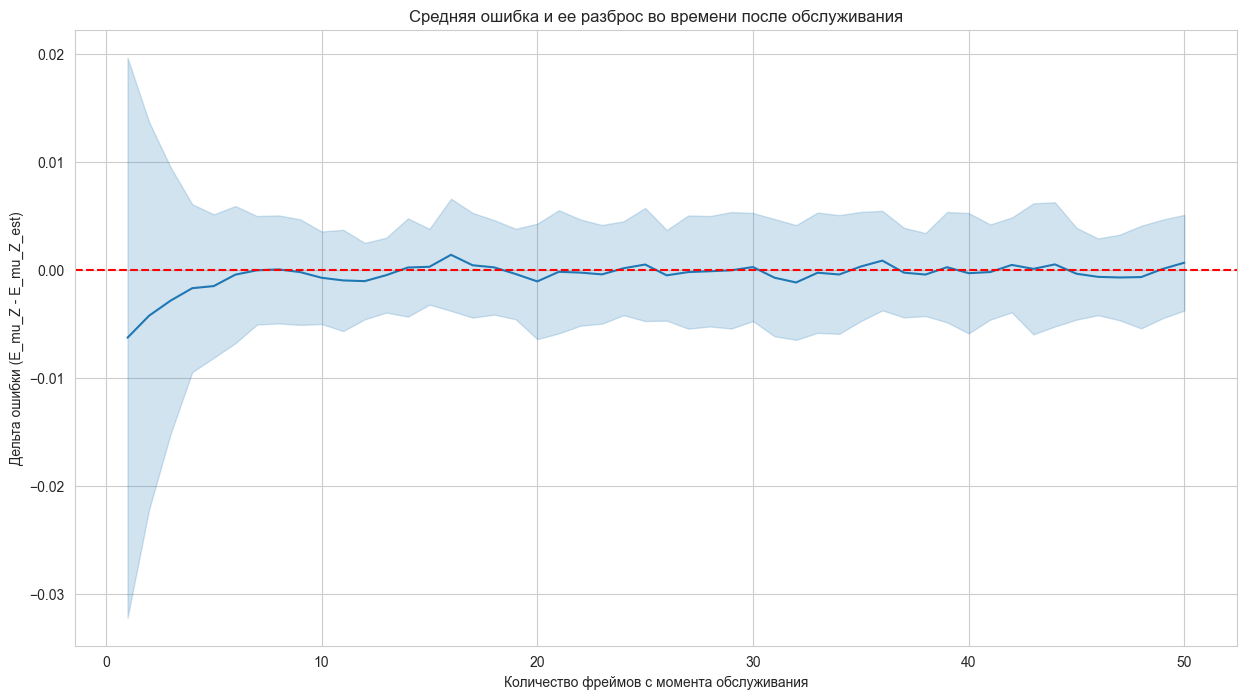

In [17]:
# Создаем признак "время с момента последнего обслуживания"
# Сначала найдем, где флаг равен 1
maintenance_indices = df[df['maintenance_flag'] == 1].index

# Создадим новую колонку
df['time_since_maintenance'] = 0

# Для каждой сессии id найдем, были ли там обслуживания
for block_id in df['id'].unique():
    block_df = df[df['id'] == block_id]
    maintenance_frames = block_df[block_df['maintenance_flag'] == 1]
    
    if not maintenance_frames.empty:
        last_maintenance_date = -1
        # Итерируемся по строкам сессии
        for idx, row in block_df.iterrows():
            if row['maintenance_flag'] == 1:
                last_maintenance_date = row['date']
            
            if last_maintenance_date != -1:
                df.loc[idx, 'time_since_maintenance'] = row['date'] - last_maintenance_date

# Посмотрим, как ошибка меняется со временем после обслуживания
plt.figure(figsize=(15, 8))
# Возьмем только первые 50 фреймов после обслуживания для наглядности
subset = df[(df['time_since_maintenance'] > 0) & (df['time_since_maintenance'] <= 50)]
sns.lineplot(x='time_since_maintenance', y='error_delta', data=subset, estimator='mean', errorbar='sd')
plt.axhline(0, color='red', linestyle='--')
plt.title('Средняя ошибка и ее разброс во времени после обслуживания')
plt.xlabel('Количество фреймов с момента обслуживания')
plt.ylabel('Дельта ошибки (E_mu_Z - E_mu_Z_est)')
plt.grid(True)
plt.show()

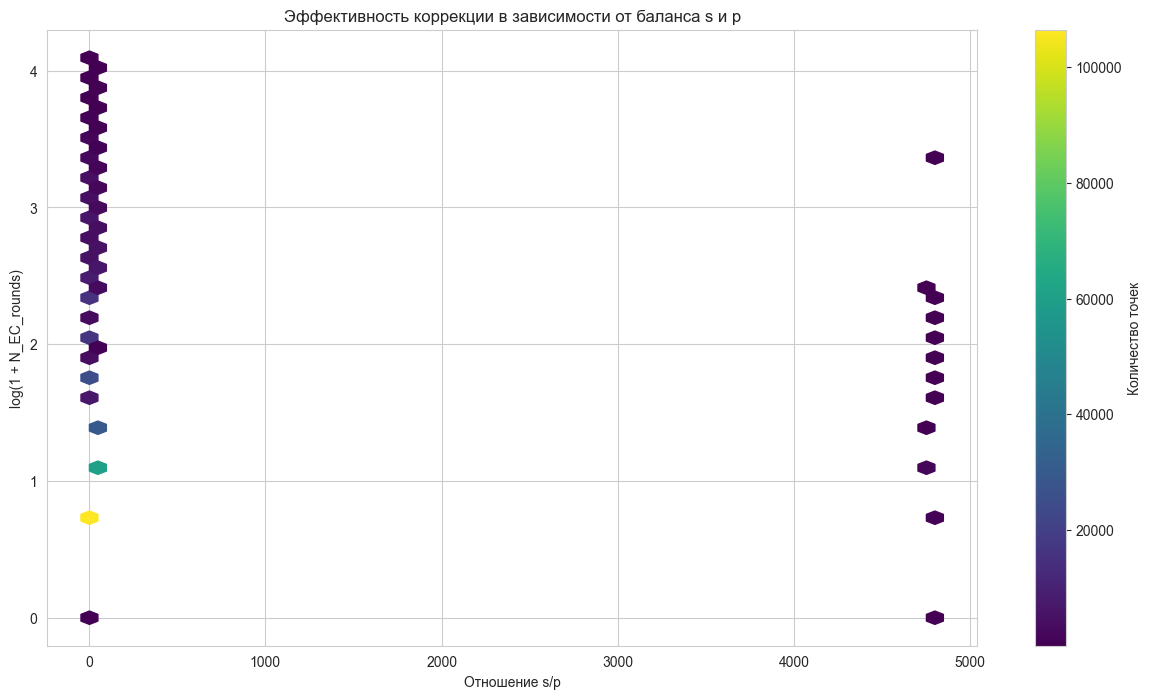

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем признак-отношение s / (p + epsilon), чтобы избежать деления на ноль
epsilon = 1
df['s_p_ratio'] = df['s'] / (df['p'] + epsilon)

# Применяем log1p к N_EC_rounds для безопасной визуализации
df['N_EC_rounds_log1p'] = np.log1p(df['N_EC_rounds'])

# Как это отношение связано с эффективностью (N_EC_rounds)?
plt.figure(figsize=(15, 8))
# Используем hexbin из-за большого количества точек.
# Теперь по оси Y откладываем уже преобразованные данные.
plt.hexbin(df['s_p_ratio'], df['N_EC_rounds_log1p'], gridsize=50, cmap='viridis', mincnt=1)
plt.colorbar(label='Количество точек')
plt.xlabel('Отношение s/p')
plt.ylabel('log(1 + N_EC_rounds)') # Обновляем подпись оси
plt.title('Эффективность коррекции в зависимости от баланса s и p')
plt.show()